# Semantic Segmentation Introduction

In this exercise, we introduce "Semantic Segmentation" of images. Semantic segmentation is a type of classification in which every pixel of an image is labeled with a specific class. Semantic segmentation corresponds to classic image classification in the field of Remote Sensing and Earth Observation. Common applications of Semantic Segmentation include Self Driving Cars that require classifying all objects and pixels of an image to localize objects such as car, pedestrian, road signs, curbs etc.

In this exercise, we use visible airbone imagery from the State of Massachussets. The goal is to detect buildings by predicting pixels that are part of buildings.  

## Dataset

The remote sensing images contains three bands in the visible spectrum: Red, Blue, Green.  There were originally made available by MASSGIS (https://www.mass.gov/orgs/massgis-bureau-of-geographic-information). In this exercise, we are using a common machine learning dataset found in the literature and provided by Volodymyr Mnih as part of his PhD thesis (https://www.cs.toronto.edu/~vmnih/data/).

Images were processed and resampled at 1 meter spatial resolution with tiles/scenes covering 2.24 km2.There are 151 images provided with:
- 137 for training
- 10 for testing
- 4 validation

Targets were generated by rasterizing footprint from Open Street Map.

## Interesting links:

- Image channel order:
https://machinelearningmastery.com/a-gentle-introduction-to-channels-first-and-channels-last-image-formats-for-deep-learning/

- rasterio reclassification:
https://www.earthdatascience.org/courses/use-data-open-source-python/intro-raster-data-python/raster-data-processing/classify-plot-raster-data-in-python/

- https://medium.com/analytics-vidhya/applying-deep-learning-on-satellite-imagery-951faa0cbb31

- Access google drive and GCS:
https://colab.research.google.com/notebooks/io.ipynb#scrollTo=RWSJpsyKqHjH

- Intro to basic Vector GIS:
https://colab.research.google.com/github/bwsi-hadr/03-Intro-to-GIS/blob/master/03_Intro_to_GIS.ipynb#scrollTo=U1VkoUkxZVeg

- UNET model:
https://colab.research.google.com/github/csaybar/EEwPython/blob/master/cnn_demo.ipynb#scrollTo=nCKDMdr0oXrf
     

In [ ]:
# Install required packages
!pip install albumentations
!pip install torch torchinfo torchmetrics kornia opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 69.1 MB/s eta 0:00:00


In [ ]:
!pip install torchinfo
# Print a summary using torchinfo (uncomment for actual output)

In [ ]:
!pip install fiona

In [ ]:
#set up libararies for GIS/Geospatial
try: # try the following block of code
  import geopandas as gpd
except: # if the try block throws an error, run the following
  !pip install geopandas # install geopandas
  import geopandas as gpd

try:
  import contextily as ctx # import
except:
  !apt install libproj-dev proj-data proj-bin
  !apt install libgeos-dev
  !pip install cython
  !pip install cartopy
  !pip install contextily==1.0rc1 --no-use-pep517 --no-cache-dir
import contextily as ctx # library for providing background maps
import fiona # library for reading/writing GIS files, comes w/ geopandas
from shapely.geometry import Point, LineString, Polygon

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libproj-dev is already the newest version (9.3.1-1~jammy0).
libproj-dev set to manually installed.
proj-data is already the newest version (9.3.1-1~jammy0).
proj-data set to manually installed.
The following NEW packages will be installed:
  proj-bin
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 205 kB of archives.
After this operation, 521 kB of additional disk space will be used.
Get:1 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 proj-bin amd64 9.3.1-1~jammy0 [205 kB]
Fetched 205 kB in 1s (203 kB/s)
Selecting previously unselected package proj-bin.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../proj-bin_9.3.1-1~jammy0_amd64.deb ...
Unpacking proj-bin (9.3.1-1~jammy0) ...
Setting up proj-bin (9.3.1-1~jammy0) ...
Processing triggers for man-db (2.10.2-1) ...
Reading package lists... Done

In [ ]:
!pip install rasterio
!pip install pyproj
!apt install unzip

#https://colab.research.google.com/github/bwsi-hadr/03-Intro-to-GIS/blob/master/03_Intro_to_GIS.ipynb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-26ubuntu3.2).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:

###### Library used in this script
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib import colors
import matplotlib.patches as mpatches
import seaborn as sns

import numpy as np
import subprocess
import pandas as pd
import os, glob
import zipfile

# Mapping,vector related imports
import geopandas as gpd
#import descartes #nessary for plotting in geopandas
from cartopy import crs as ccrs
from pyproj import Proj
#from osgeo import osr
from shapely.geometry import Point
from shapely.geometry import box
from collections import OrderedDict

#ML imports
import sklearn
from sklearn import metrics
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

#rasterio imports, gdal and imagery utility
import rasterio
from rasterio.windows import Window
from osgeo import gdal
from rasterio import plot
from PIL import Image

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

#Keras import
from tensorflow import keras
#from keras.models import Model

from pathlib import Path


from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Conv2D, Concatenate, Activation, MaxPool2D, UpSampling2D, Conv2DTranspose
from tensorflow.keras import models
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model


sns.set_style('darkgrid')
pd.set_option('display.max_colwidth', None)

In [ ]:
#Used in defining functions
from typing import List, Tuple, Dict, Any
from pandas.core.arrays import boolean

The packages above are some of the most frequently used for geospatial data processing, wrangling and analysis. Notables packages are geopandas, rasterio, pysal, gdal and shapely. Geopandas extends the pandas package to allow for the use of spatial data using a geometry column in a DataFrame. It implements a version of the Simple Feature model (https://www.opengeospatial.org/standards/sfa) using the "shapely" package to define the geometry of spatial objects. GDAL and Rasterio allows operations and processing on raster layers. Pysal provide spatial analyses tools such as Moran's I and spatial regression modeling. In this exercise, we also use the "keras" package that implements deep learning models at high abstraction level.

## Functions
In the next part of the script, we declare all the functions used in the sripts.  It is good practice to place functions at the beginning of a script or in an external source file. Here are the functions used:

* **create_dir_and_check_existence**:  create and output directory given a path. The output directory will be the working directory throughout the analysis.

* **generate_files_data_df**: generate a list of image files with path and type. There are three types of files used in this application: training, testing and validation. Each RGB image (X input) has corresponding target image Y (output).
We used the file structure from Volodymyr Mnih (https://www.cs.toronto.edu/~vmnih/data/).)

* **generate_image_chips**; generate image chips/patches that are in this script 256x256 cropped images taken randomly within the remotely sensed images. These image chips are used to train, validate and test the deep learning model.

* **image_data_generator**: generate batch of data to use in the deep learning model. The dataset being to large, an image chip is provided one at a time when fiting the deep learning model.

* **plot_roc**: generate ROC plots using a reference and a predicted image. AUC
values are also returned for testing and training if provided.

* **compute_iou_dice_metrics**: geneate IOU (aka Jaccard index) and dice metrics to evaluate the classification.

* **binary_crosstab_array**: generate error map for boolean (0,1) reference and predicted raster (input format as np.array).



In [ ]:
def create_dir_and_check_existence(path):

    #Create a new directory
    try:
        os.makedirs(path)
    except:
        print ("directory already exists")

from matplotlib import pyplot


def generate_files_data_df(in_path):
    """
    Generate data frame for the input raster files. This function assumes a specific directory tree structure.
    We use the structure from provided by Volodymyr Mnih as part of his PhD thesis (https://www.cs.toronto.edu/~vmnih/data/).
    This data is also used in numerous publication. The data frame will contain for each scene id, a corresponding
    sat (RGB aerial imagery) and map (classfied building image) as well as label named 'type' corresponding to
    train, test, and validation data.

    Input Arguments:

    in_path: parent directory path to the data files

    Return Outputs:

    files_df: pandas data frame containing directory path to training, testing and validation images.

    """

    fileglob = "*.tiff"
    path_raster_sat = os.path.join(in_path+'/**/sat/',fileglob) #raw raster
    fileglob = "*.tif"
    path_raster_map = os.path.join(in_path+'/**/map/',fileglob) #classified

    files_raster_sat = glob.glob(path_raster_sat,recursive=True)
    files_raster_map = glob.glob(path_raster_map,recursive=True)

    files_map_df = pd.DataFrame({'files_map':files_raster_map})
    files_sat_df = pd.DataFrame({'files_sat':files_raster_sat})

    files_sat_df['scene_id_sat'] = files_sat_df['files_sat'].apply(lambda x: os.path.basename(x).replace('.tiff',""))
    files_map_df['scene_id_map'] = files_map_df['files_map'].apply(lambda x: os.path.basename(x).replace('.tif',""))

    files_df = (files_sat_df.merge(files_map_df,
                                  left_on='scene_id_sat',
                                  right_on='scene_id_map',
                                  how='inner')
                             .drop(columns=['scene_id_map'])
                             .rename(columns={'scene_id_sat':'scene_id'})
               )
    files_df['type']= files_df['files_sat'].apply(lambda x: os.path.basename(os.path.dirname(os.path.dirname(x)))) #make it more elegant later

    return files_df



In [ ]:

def generate_image_chips(in_file,
                         image_size=32,
                         row_offset=None,
                         col_offset=None,
                         rescale=None,
                         out_file=None,
                         shape_file=None,
                         plot=False):
    '''
    This function generates image subsets called chips given an input file and a series of arguments.

    Input Arguments:

    in_file: input file name, this assumes 3 bands
    image_size: default size (height=width) for the image chip/subset produced.
    row_offset: row/height offset provided, if none this is generated on the fly randomly
    col_offset: col/width offset provided, if none this is generated on the fly randomly
    rescale: not implemented yet, option to rescale the image, default is None
    out_file: not implemented yet, option to save the image chip, default is None
    shape_file: not implemented yet,option to use a shape file to crop the image and generate chip, default is None
    plot: generate plot using RGB bands, default option is False

    Return Outputs:

    w_image: chip/cropped image with size image_size x image_size return as a numpy array with 3 channels/bands
    df_chip: pandas data frame containing meta data including row and column offset
             used in sampling the image chip as well as
             the coordinates of the extent/bounding box of the image chip,
             original file used and the scene id.

    '''

    raster = rasterio.open(in_file)
    height_val = raster.height #row in remote sensing image
    width_val  = raster.width  #col in remote sensing image
    channel_val = raster.count #band in remote sensing image

    if row_offset is None:
        limit_row = height_val - image_size #the new image chip cannot exceed the limit of the image otherwise it will not have the expected size
        row_offset = np.random.randint(0,
                                       limit_row,
                                       size=1)

    if col_offset is None:
        limit_col = width_val - image_size #the new image chip cannot exceed the limit of the image otherwise it will not have the expected size
        col_offset = np.random.randint(0,
                                       limit_col,
                                       size=1)

    channel_list = np.arange(1,channel_val+1).tolist()

    if shape_file==None:
        with rasterio.open(in_file) as src:
            w_image = src.read(channel_list,
                  window=Window(row_offset,
                                col_offset,
                                image_size,
                                image_size))
    scene_id=os.path.basename(in_file)

    if plot==True:
        #Generate quick visualization using rasterio object
        f, ax = plt.subplots(1, 3,figsize=(16,16))

        rasterio.plot.show(w_image[0],title=scene_id+" band_1",ax=ax[0])
        rasterio.plot.show(w_image[1],title=scene_id+" band_2",ax=ax[1])
        rasterio.plot.show(w_image[2],title=scene_id+" band_3",ax=ax[2])

    #Finish this option later
    #if out_file!= None:
    #    w_image.write

    if rescale is not None:
        w_image = w_image.astype('float64')
        for i in range(0,len(channel_list)):
            w_image[i,:,:] = w_image[i,:,:] * rescale

    if isinstance(row_offset,np.ndarray):
        row_offset= row_offset[0]
    if isinstance(col_offset,np.ndarray):
        col_offset= col_offset[0]

    x_offset_l_top,y_offset_l_top = raster.xy(row_offset,
                                              col_offset) #topleft of image chip
    x_offset_r_bottom,y_offset_r_bottom = raster.xy(row_offset+image_size,
                                                    col_offset+image_size)

    df_chip=pd.DataFrame({"scene_id":[scene_id],
                          "col_offset":[col_offset],
                          "row_offset":[row_offset],
                          "image_size":[image_size],
                          "x_min": [x_offset_l_top],
                          "y_min": [y_offset_l_top],
                          "x_max": [x_offset_r_bottom],
                          "y_max": [y_offset_r_bottom],
                          "file":[in_file]})
    return w_image, df_chip

In [ ]:


def image_data_generator(image_files_df,subset="train",rescale=1./255,image_size=256,batch_size=32):
    '''
    This is an image data generator for spatial images. It uses rasterio window to sample randomly image chips and return images.
    to train/validate/test a network.
    Note that this function assumes a specific format for the input data frame used to describe the data.
    The data frame should contain four columns: files_map,files_sat, scene_id and type.

    Input Arguments:

    image_files_df: data frame containing the path names for input features, target and type
    subset: subset data frame for training, validation or testing, default is "train", selected using column 'type'.
    rescale: rescale factor for the input images, default is 1./255
    image_size: image size generated from input by subset, default is 256 (height=width)
    batch_size: number of batches, default is 32

    Return Outputs:

    batch_image_X: Input feature numpy array containing batch of image arrays (height, width, channel)
    batch_image_Y: Target nnumpy array containing batch of image arrays (height, width, channel)

    '''

    while True:
        in_files_df = (image_files_df.loc[image_files_df['type']==subset,:]
                                     .sample(n = batch_size)
                      )

        list_w_image_X = []
        list_w_image_Y = []
        list_df_chip_X = []
        list_df_chip_Y = []

        for i in range(0,batch_size):
            w_image_X, df_chip_X = generate_image_chips(in_files_df['files_sat'].iloc[i],
                             image_size=image_size,
                             row_offset=None,
                             col_offset=None,
                             rescale=1./255.,
                             out_file=None,
                             shape_file=None,
                             plot=False)
            # for Y:
            w_image_Y, df_chip_Y = generate_image_chips(in_files_df['files_map'].iloc[i],
                             image_size=image_size,
                             row_offset=df_chip_X['row_offset'].iloc[0],#use offset from input feature images
                             col_offset=df_chip_X['col_offset'].iloc[0],
                             rescale=1./255.,
                             out_file=None,
                             shape_file=None,
                             plot=False)

            if rescale is not None:
                #not yet implemented
                print()
                channel_val = raster.count #band
                channel_list = np.arange(1,channel_val+1).tolist()

                w_image = w_image.astype('float64')
                for i in range(0,len(channel_list)):
                  w_image_X[i,:,:] = w_image_X[i,:,:] * rescale


            list_w_image_X.append(w_image_X)
            list_w_image_Y.append(w_image_Y)
            list_df_chip_X.append(df_chip_X)
            list_df_chip_Y.append(df_chip_Y)

        #return only images,
        batch_image_X=np.stack(list_w_image_X)
        batch_image_Y=np.stack(list_w_image_Y)

        batch_image_X = np.moveaxis(batch_image_X, 1, 3) #move axis 1 to 3, i.e. channel axis should be last.
        batch_image_Y = np.moveaxis(batch_image_Y, 1, 3) #move axis 1 to 3, this is necessary later for keras.
        #batch_image_Y = batch_image_Y[:,:,:,0] #this removes the fourth dimension
        batch_image_Y = batch_image_Y[:,:,:,:1]

        yield  batch_image_X, batch_image_Y


In [ ]:
def generate_raster_image_chips(in_file,
                         image_size=32,
                         row_offset=None,
                         col_offset=None,
                         out_file=None,
                         out_dir=None,
                         out_prefix=None,
                         return_image=False): #return image if not

    '''
    This function generates image subsets called chips given an input file and a series of arguments.

    Input Arguments:

    in_file: input file name, this assumes 3 bands
    image_size: default size (height=width) for the image chip/subset produced.
    row_offset: row/height offset provided, if none this is generated on the fly randomly
    col_offset: col/width offset provided, if none this is generated on the fly randomly
    rescale: not implemented yet, option to rescale the image, default is None
    out_file: not implemented yet, option to save the image chip, default is None
    shape_file: not implemented yet,option to use a shape file to crop the image and generate chip, default is None
    plot: generate plot using RGB bands, default option is False

    Return Outputs:

    w_image: chip/cropped image with size image_size x image_size return as a numpy array with 3 channels/bands
    df_chip: pandas data frame containing meta data including row and column offset
             used in sampling the image chip as well as
             the coordinates of the extent/bounding box of the image chip,
             original file used and the scene id.

    '''


    raster = rasterio.open(in_file)
    height_val = raster.height #row in remote sensing image
    width_val  = raster.width  #col in remote sensing image
    channel_val = raster.count #band in remote sensing image

    if row_offset is None:
        limit_row = height_val - image_size #the new image chip cannot exceed the limit of the image otherwise it will not have the expected size
        row_offset = np.random.randint(0,
                                        limit_row,
                                        size=1)

    if col_offset is None:
        limit_col = width_val - image_size #the new image chip cannot exceed the limit of the image otherwise it will not have the expected size
        col_offset = np.random.randint(0,
                                        limit_col,
                                        size=1)

    channel_list = np.arange(1,channel_val+1).tolist()

    if isinstance(row_offset,np.ndarray):
      row_offset= row_offset[0]
    if isinstance(col_offset,np.ndarray):
      col_offset= col_offset[0]

    x_offset_l_top,y_offset_l_top = raster.xy(row_offset,
                                          col_offset) #topleft of image chip
    x_offset_r_bottom,y_offset_r_bottom = raster.xy(row_offset+image_size,
                                                col_offset+image_size)

    from rasterio.windows import Window
    from rasterio.transform import Affine

    # Define the window (col_off, row_off, width, height)
    window = Window(row_offset, col_offset, image_size, image_size)

    #if shape_file==None:
    with rasterio.open(in_file) as src:
      w_image = src.read(window=window)#reading all chaneels

    # Update metadata for the new raster
    profile = raster.profile
    transform = raster.window_transform(window)
    profile.update({
            'height': w_image.shape[1],
            'width': w_image.shape[2],
            'transform': transform
    })

    # Write the data to a new raster file
    scene_id = os.path.basename(in_file)
    scene_id = Path(scene_id).stem


    out_filename = f'{out_prefix}_{row_offset}_{col_offset}_{image_size}_{scene_id}.tif'
    out_filename = os.path.join(out_dir,out_filename)
    with rasterio.open(out_filename, 'w', **profile) as dst:
        dst.write(w_image)

    df_chip=pd.DataFrame({"scene_id":[scene_id],
                      "col_offset":[col_offset],
                      "row_offset":[row_offset],
                      "image_size":[image_size],
                      "x_min": [x_offset_l_top],
                      "y_min": [y_offset_l_top],
                      "x_max": [x_offset_r_bottom],
                      "y_max": [y_offset_r_bottom],
                      "file":[in_file],
                      "out_file":[out_filename]})
    if return_image==True:
        return w_image, df_chip
    else:
        return df_chip


In [ ]:
def produce_image_chips(out_dir_str,n_chips,type_split,files_df,random_seed=42):

  if random_seed is not None:
    np.random.seed(random_seed)

  in_files_df = (files_df.loc[files_df['type']==type_split,:]
                                      .sample(n = n_chips,replace=True)
                          .reset_index(drop=True)
                        )
  list_chip_img_features_df = []
  list_chip_img_labels_df = []

  for i in range(0,n_chips):

    in_filename_image_feature = in_files_df.loc[i,'files_sat']
    in_filename_image_labels = in_files_df.loc[i,'files_map']

    df_chip_image_features_tmp = generate_raster_image_chips(in_filename_image_feature,
                            image_size=256,
                            row_offset=None,
                            col_offset=None,
                            out_file=None,
                            #out_dir=os.path.join(out_dir,'data','train','img_features'),
                            out_dir=os.path.join(out_dir_str,'img_features'),
                            out_prefix=f'feature_patch_{i}',
                            return_image=False) #return image if not


    df_chip_image_labels_tmp = generate_raster_image_chips(in_filename_image_labels,
                            image_size=256,
                            row_offset=df_chip_image_features_tmp['row_offset'].iloc[0],#use offset from input feature images
                            col_offset=df_chip_image_features_tmp['col_offset'].iloc[0],
                            out_file=None,
                            #out_dir=os.path.join(out_dir,'data','train','img_labels'),
                            out_dir=os.path.join(out_dir_str,'img_labels'),
                            #out_dir=
                            out_prefix=f'label_patch_{i}',
                            return_image=False) #return image if not
    list_chip_img_features_df.append(df_chip_image_features_tmp)
    list_chip_img_labels_df.append(df_chip_image_labels_tmp)



  chips_img_features_df = pd.concat(list_chip_img_features_df).reset_index(drop=True)
  chips_img_labels_df = pd.concat(list_chip_img_labels_df).reset_index(drop=True)
  chips_img_df = chips_img_features_df.copy()
  chips_img_df['label_file'] = chips_img_labels_df['out_file']
  chips_img_df['type'] = type_split
  chips_img_df = chips_img_df.rename(columns={'out_file':'feature_file'})

  return chips_img_df

In [ ]:
def plot_roc(y_test,
             y_scores_test,
             y_scores_train=None,
             y_train=None,
             model_name=None,
             show_fig=True,
             out_file=None):
    '''
    This functions gnerate an ROC plot curve and AUC metric.

    Input Arguments:

    y_test: input one dimension array containing test label/target
    y_scores_test: input one dimension array containing predicted test scores (between 0 and 1)
    y_scores_train: input one dimension array containing predicted train scores (between 0 and 1),
                    default is None
    y_train:input one dimension array containing train scores (between 0 and 1),
            default is None.
    model_name: string containing model name (e.g. UNET), default is None
    show_fig:if True, ROC plot is shown.
    out_file: name of output file for ROC plot
              if None, a default name is set.

    Return Outputs:

    roc_df: DataFrame with three columns: threshold, False Positive Rate (fpr) and True Positive Rate (tpr)
    auc_df: DataFrame with three columns: test AUC ('test', train AUC ('train'),model name ('model')

    '''

    if model_name is None:
        model_name = 'model'
    # Now check the number of 1 and 0
    unique, counts = np.unique(y_test, return_counts=True)
    if len(unique) > 1:
      auc_val_test =roc_auc_score(y_test,y_scores_test)
    else:
      auc_val_test = np.nan

    if y_scores_train is None:
        auc_val_train = np.nan
    elif y_train is None:
        auc_val_train = np.nan
    else:
        auc_val_train = roc_auc_score(y_train,
                                      y_scores_train)

    if len(unique) > 1:
      print("AUC train: ", auc_val_train)
      print("AUC test: ", auc_val_test)

      #Generate inputs for ROC curves
      fpr, tpr, thresholds = roc_curve(y_test,
                                     y_scores_test)
      plt.figure()
      label_val = '%s (area= %0.2f)' % (model_name,auc_val_test)

      plt.plot(fpr, tpr,
             label=label_val)

      plt.plot([0, 1], [0, 1],'r--')
      plt.xlim([0.0, 1.0])
      plt.ylim([0.0, 1.05])
      plt.xlabel('False Positive Rate')
      plt.ylabel('True Positive Rate')
      plt.title('Test ROC')
      plt.legend(loc="lower right")
    else:
      thresholds = [np.nan]
      tpr= [np.nan]
      fpr = [np.nan]

    if out_file is None:
       out_file = model_name + '_roc_curve.png'

    plt.savefig(out_file)

    if show_fig == True:
        plt.show()
    else:
        plt.close()

    roc_df = pd.DataFrame({'thresholds': thresholds,
                           'tpr': tpr,
                           'fpr': fpr})

    auc_df = pd.DataFrame(np.array([[auc_val_test],[auc_val_train],[model_name]]).reshape(1,3),
                         columns=['test','train','model'])

    return roc_df, auc_df


def plot_roc(y_test,
             y_scores_test,
             y_scores_train=None,
             y_train=None,
             model_name=None,
             show_fig=True,
             out_file=None):
    '''
    This functions gnerate an ROC plot curve and AUC metric.

    Input Arguments:

    y_test: input one dimension array containing test label/target
    y_scores_test: input one dimension array containing predicted test scores (between 0 and 1)
    y_scores_train: input one dimension array containing predicted train scores (between 0 and 1),
                    default is None
    y_train:input one dimension array containing train scores (between 0 and 1),
            default is None.
    model_name: string containing model name (e.g. UNET), default is None
    show_fig:if True, ROC plot is shown.
    out_file: name of output file for ROC plot
              if None, a default name is set.

    Return Outputs:

    roc_df: DataFrame with three columns: threshold, False Positive Rate (fpr) and True Positive Rate (tpr)
    auc_df: DataFrame with three columns: test AUC ('test', train AUC ('train'),model name ('model')

    '''

    if model_name is None:
        model_name = 'model'
    # Now check the number of 1 and 0
    unique, counts = np.unique(y_test, return_counts=True)
    if len(unique) > 1:
      auc_val_test =roc_auc_score(y_test,y_scores_test)
    else:
      auc_val_test = np.nan

    if y_scores_train is None:
        auc_val_train = np.nan
    elif y_train is None:
        auc_val_train = np.nan
    else:
        auc_val_train = roc_auc_score(y_train,
                                      y_scores_train)

    if len(unique) > 1:
      print("AUC train: ", auc_val_train)
      print("AUC test: ", auc_val_test)

      #Generate inputs for ROC curves
      fpr, tpr, thresholds = roc_curve(y_test,
                                     y_scores_test)
      plt.figure()
      label_val = '%s (area= %0.2f)' % (model_name,auc_val_test)

      plt.plot(fpr, tpr,
             label=label_val)

      plt.plot([0, 1], [0, 1],'r--')
      plt.xlim([0.0, 1.0])
      plt.ylim([0.0, 1.05])
      plt.xlabel('False Positive Rate')
      plt.ylabel('True Positive Rate')
      plt.title('Test ROC')
      plt.legend(loc="lower right")
    else:
      thresholds = [np.nan]
      tpr= [np.nan]
      fpr = [np.nan]

    if out_file is None:
       out_file = model_name + '_roc_curve.png'

    plt.savefig(out_file)

    if show_fig == True:
        plt.show()
    else:
        plt.close()

    roc_df = pd.DataFrame({'thresholds': thresholds,
                           'tpr': tpr,
                           'fpr': fpr})

    auc_df = pd.DataFrame(np.array([[auc_val_test],[auc_val_train],[model_name]]).reshape(1,3),
                         columns=['test','train','model'])

    return roc_df, auc_df

In [ ]:
#Original code from coursera for iou and dice scores,
#Modified by Benoit to fix some issues, especially nan related
def compute_iou_dice_metrics(y_true, y_pred,n_classes=2):
  '''
  Computes IOU and Dice Score.

  Args:
    y_true (tensor) - ground truth label map
    y_pred (tensor) - predicted label map
  '''

  class_iou = []
  class_dice_score = []

  unique, counts = np.unique(y_true, return_counts=True)
  if len(unique) > 1:
    smoothening_factor = 0.00001 #avoid if there is a class with zero frequency
    #np.unique(y_true)
    for i in np.arange(0,n_classes):
      intersection = np.sum((y_pred == i) * (y_true == i))
      y_true_area = np.sum((y_true == i))
      y_pred_area = np.sum((y_pred == i))
      combined_area = y_true_area + y_pred_area

      iou = (intersection + smoothening_factor) / (combined_area - intersection + smoothening_factor)
      class_iou.append(iou)

      dice_score =  2 * ((intersection + smoothening_factor) / (combined_area + smoothening_factor))
      class_dice_score.append(dice_score)
  else:
    for i in np.arange(0,n_classes):
      iou=np.nan
      dice_score=np.nan
      class_dice_score.append(dice_score)
      class_iou.append(iou)

  return class_iou, class_dice_score

In [ ]:
def binary_crosstab_array(arr1,arr2):

  """
  This function generates a crosstab numpy array given two input arrays.
  The first array 'arr1' can be taken as a reference to which the
  second array (arr2) is compared. One can think of arr2 as the prediction.
  Note that the arrays are assumed to be boolean with values 0 or 1.
  The output is a new array with four values 0,1,2,3 corresponding respectively
  to True Negative (TN), True Positive (TP), False Positive (FP) and False Negative (FN).

  TO DO:   Add later testing for number of rows and cols matching to avoid error

  Input Arguments:
  arr1: reference array (numpy type)
  arr2: predicted array (numpy type)

  Return Outputs:
  arr_new: reclassified output array with confusion matrix including TP, TN,FP, FN
  df_label_new: data frame with values and corresponding labels used in arr_new

  """

  row,col = arr1.shape #get height/row and width/col

  arr_new = np.empty(arr1.shape, dtype=int) #new output array with values reclassified as TN,TP,FP,FN

  for i in range(0,row):
    for j in range(0,col):
      if (arr1[i,j]==arr2[i,j]) and (arr1[i,j]==0) :
        arr_new[i,j]=0 #True Negative (TN)
      if (arr1[i,j]==arr2[i,j]) and (arr1[i,j]==1) :
        arr_new[i,j]=1 #True Positive (TP)
      if (arr1[i,j]!=arr2[i,j]) and (arr1[i,j]==0) :
        arr_new[i,j]=2 # False Positive (FP)
      if (arr1[i,j]!=arr2[i,j]) and (arr1[i,j]==1) :
        arr_new[i,j]=3 # False Negative (FN)

  df_label_new = pd.DataFrame({"val": [0,1,2,3],
                                "label":["TN","TP","FP","FN"]
                              })
  return arr_new, df_label_new


In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Parameters and Arguments

It is good practice to set all parameters and input arguments at the beginning of the script. This allows for better control and can make modifications of the scripts for other applications easier. Some arguments relate to path directories, input files and general parameters for use in the analyses (e.g. proportion of hold out).


In [ ]:
############################################################################
#####  Parameters and argument set up ###########

#ARG 1
in_dir = '/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/'
#ARG 2
out_dir = "/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation"
#ARGS 3:
create_out_dir=True #create a new ouput dir if TRUE
#ARG 4
out_suffix = "semantic_seg_pytorch_20260228" #output suffix for the files and ouptut folder
#ARG 5
NA_value = -9999 # currently not used: Nan value
#ARG 6
random_seed=105 # set seed for reproducibility of results

#ARG 7
## Input data
data_dir ='/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data'
#ARG 8
#generate_files_chips = False
generate_files_chips = True


run_model = False #if True, model is trained, note this may take several hours.
#ARG 9
# Use pre-trained model if run_model is False
model_path ='/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/models/model_output_20260227'


In [ ]:
################# START SCRIPT ###############################

######### PART 0: Set up the output dir ################

#set up the working directory
#Create output directory

if create_out_dir==True:
    out_dir_new = "output_data_"+out_suffix
    out_dir = os.path.join(out_dir,"outputs",out_dir_new)
    create_dir_and_check_existence(out_dir)
    os.chdir(out_dir)        #set working directory
else:
    os.chdir(out_dir) #use working dir defined earlier


directory already exists


In [ ]:
print(out_dir)

/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228


# Workflow/pipeline

We describe here the modeling pipelin we set up for this exercise:
1. **Download**
- Obtain data from the website or link provided in the exercise.
2. **Explore data and set up list**
- Prepare data frame with list of files as input in the training and for the generator.
-Visualize feature images and target image.
3. **Generate image chip/patch data for training and modeling**
- use the image data generator to generate image chips to feed in during the model fitting/training.
4. **Build and train model**
- build UNET keras model
- train model using the image data generator
5. **Accuracy Assessment**
- use test data to generate an accuracy assessment
- assess accuracy with ROC plot and AUC.



# 1.Download/Unzip Data

Dowload data from the following google drive link. Once it is downloaded, you will need to place and upload the zipped file in your own google drive directory. The suggested path for the zipped file 'mass_building.zip' is in '/intro_semantic_segmentation/data/.

### Data structure

The data is organized in three main directories: train, test and valid.
The map 'directory' contains classified boolean image (with 0 not build and 1 being built) and 'sat' contains the RBG aerial imagery in tiff format. Every image contains a scene id with matching scene id in the map directory.
Once unzipped, you should be able to see the following directory tree structure:

```
mass_buildings/
            /train/
                  /map/<scene_id>.tif
                  /sat/<scene_id>.tif
            /test
                 /map/<scene_id>.tif
                 /sat/<scene_id>.tif
            /valid
                 /map/<scene_id>.tif
                 /sat/<scene_id>.tif
```

This steps takes between 3 and 6 minutes.

In [ ]:
#extract data using zipfile

zip_files = zipfile.ZipFile(os.path.join(data_dir,'mass_buildings.zip'))
zip_files.extractall(data_dir)
data_dir = os.path.join(data_dir, "mass_buildings")


#2.Explore data display images

In [ ]:
files_df = generate_files_data_df(data_dir).reset_index(drop=True)
files_df.head()

,files_sat,scene_id,files_map,type
0,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/valid/sat/23728930_15.tiff,23728930_15,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/valid/map/23728930_15.tif,valid
1,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/valid/sat/23579050_15.tiff,23579050_15,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/valid/map/23579050_15.tif,valid
2,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/valid/sat/22978945_15.tiff,22978945_15,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/valid/map/22978945_15.tif,valid
3,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/valid/sat/23429155_15.tiff,23429155_15,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/valid/map/23429155_15.tif,valid
4,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/test/sat/22829050_15.tiff,22829050_15,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/test/map/22829050_15.tif,test


In [ ]:
files_df.type.value_counts()

,count
type,
train,137
test,10
valid,4


In [ ]:
print(files_df.loc[0,['files_sat']])
print(files_df.loc[0,['files_map']])
print(files_df.loc[0,['scene_id']])

files_sat    /content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/valid/sat/23728930_15.tiff
Name: 0, dtype: object
files_map    /content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/valid/map/23728930_15.tif
Name: 0, dtype: object
scene_id    23728930_15
Name: 0, dtype: object


In [ ]:
r_sat = rasterio.open(files_df['files_sat'][0])
r_map = rasterio.open(files_df['files_map'][0])
scene_id = files_df.loc[0,['scene_id']]
print(type(r_sat))
print("Coordinate reference system: ",r_sat.crs )
print(type(r_map))
print("Coordinate reference system: ",r_map.crs )
print(" Rows and columns: ", r_sat.shape, "number of rows/height: ", r_sat.height, "number of columns/width",r_sat.width)


<class 'rasterio.io.DatasetReader'>
Coordinate reference system:  EPSG:26986
<class 'rasterio.io.DatasetReader'>
Coordinate reference system:  EPSG:26986
 Rows and columns:  (1500, 1500) number of rows/height:  1500 number of columns/width 1500


In [ ]:
print(type(r_sat.meta))
r_sat.meta

<class 'dict'>


{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 1500,
 'height': 1500,
 'count': 3,
 'crs': CRS.from_wkt('PROJCS["NAD83 / Massachusetts Mainland",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",41],PARAMETER["central_meridian",-71.5],PARAMETER["standard_parallel_1",42.6833333333333],PARAMETER["standard_parallel_2",41.7166666666667],PARAMETER["false_easting",200000],PARAMETER["false_northing",750000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26986"]]'),
 'transform': Affine(1.0000000000000195, 0.0, 236486.43617399578,
        0.0, -0.9999999999999225, 893771.0247782532)}

<Axes: title={'center': 'scene_id_mapped'}>

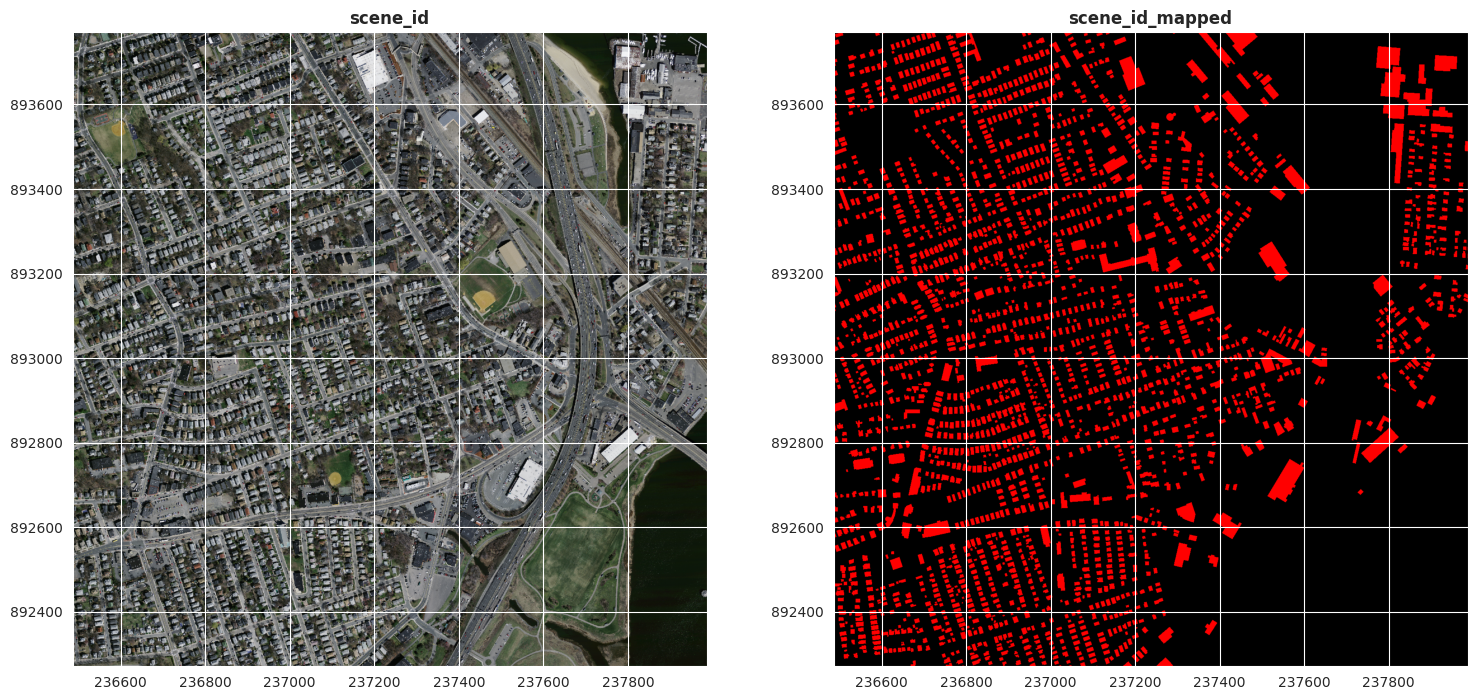

In [ ]:
#Generate quick visualization using rasterio object
scene_id="scene_id"
f, ax = plt.subplots(1, 2,figsize=(18,18))
plot.show(r_sat,title=scene_id,ax=ax[0])
plot.show(r_map,title=scene_id+"_mapped",ax=ax[1])

In [ ]:
arr = r_sat.read()  # read all raster values as numpy array
display(type(arr))
arr.shape

numpy.ndarray

(3, 1500, 1500)

In [ ]:
arr = r_map.read()  # read all raster values
display(type(arr))
arr.shape

numpy.ndarray

(3, 1500, 1500)

In [ ]:
unique_elements, counts_elements = np.unique(arr[0,:,:], return_counts=True)
print("Frequency of unique values of the said array:")
print(np.asarray((unique_elements, counts_elements)))


Frequency of unique values of the said array:
[[      0     255]
 [1911181  338819]]


In [ ]:
unique_elements, counts_elements = np.unique(arr[1,:,:], return_counts=True)
print("Frequency of unique values of the said array:")
print(np.asarray((unique_elements, counts_elements)))


Frequency of unique values of the said array:
[[      0]
 [2250000]]


In [ ]:
unique_elements, counts_elements = np.unique(arr[2,:,:], return_counts=True)
print("Frequency of unique values of the said array:")
print(np.asarray((unique_elements, counts_elements)))

Frequency of unique values of the said array:
[[      0]
 [2250000]]


#3.Generate image chip/patch data for training and modeling


This includes two steps:
1. generate images chips
2. include image chips in a generator or a pythorch dataset class.

 ## 3.1 Saving image chips to file

Le'ts first show how we can create an image chip and save.

Let's create the tree structures to store the data

In [ ]:
for type_split in ['train','test','valid']:
  if not os.path.exists(os.path.join(out_dir,'data',type_split,'img_labels')):
    os.makedirs(os.path.join(out_dir,'data',type_split,'img_labels'))
for type_split in ['train','test','valid']:
  if not os.path.exists(os.path.join(out_dir,'data',type_split,'img_features')):
    os.makedirs(os.path.join(out_dir,'data',type_split,'img_features'))

First let use the function created to show how an image patch/chip is created for the training. The logic is as follow:

- randomly select n_chips (e.g. 400) images from specific split type e.g. from training
- choose an image size for example 256 for the image patch
- provide the pixel offset width and height for the top letf corner of the image patch or randomly select it (set None in the function).
- provide correct path to store the image patch tif

In [ ]:
type_split = 'train'
n_chips=400
in_files_df = (files_df.loc[files_df['type']==type_split,:]
                                     .sample(n = n_chips,replace=True)
                        .reset_index(drop=True)
                      )
i = 0
in_filename_image_feature = in_files_df.loc[i,'files_sat']
in_filename_image_labels = in_files_df.loc[i,'files_map']
#scene_id = files_df.loc[0,['scene_id']]

df_chip_image_features_tmp = generate_raster_image_chips(in_filename_image_feature,
                         image_size=256,
                         row_offset=None,
                         col_offset=None,
                         out_file=None,
                         out_dir=out_dir,
                         out_prefix=f'test_feature_patch_{i}',
                         return_image=False) #return image if not


df_chip_image_labels_tmp = generate_raster_image_chips(in_filename_image_labels,
                         image_size=256,
                         row_offset=df_chip_image_features_tmp['row_offset'].iloc[0],#use offset from input feature images
                         col_offset=df_chip_image_features_tmp['col_offset'].iloc[0],
                         out_file=None,
                         out_dir=out_dir,
                         out_prefix=f'test_labels_patch_{i}',
                         return_image=False) #return image if not

df_chip_image_features_tmp


,scene_id,col_offset,row_offset,image_size,x_min,y_min,x_max,y_max,file,out_file
0,23428900_15,131,322,256,233617.936,890448.525,233873.936,890192.525,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/train/sat/23428900_15.tiff,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/test_feature_patch_0_322_131_256_23428900_15.tif


In [ ]:
!ls -ltr $'{out_dir}' #avoid issues with space in the path

total 780
-rw------- 1 root root 198524 Feb 28 22:18 test_labels_patch_0_244_744_256_24029035_15.tif
-rw------- 1 root root 198524 Feb 28 22:18 test_feature_patch_0_244_744_256_24029035_15.tif
drwx------ 5 root root   4096 Feb 28 22:18 data
-rw------- 1 root root 198524 Mar  1 18:39 test_labels_patch_0_322_131_256_23428900_15.tif
-rw------- 1 root root 198524 Mar  1 18:39 test_feature_patch_0_322_131_256_23428900_15.tif


In [ ]:
!pwd

/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228


We can generate the n_chips images chips using the folder structure defined earlier.
If the files are already present, we can set the parameters generate_files_chips = false. This steps takes about a minute.

In [ ]:
if generate_files_chips is True:

  #1min and 11sec
  list_type_split = ['train','test','valid']
  list_type_n_chips = [400,100,100]
  #list_type_n_chips = [8,2,2]
  list_chips_img_df = []
  for type_split,n_chips in zip(list_type_split,list_type_n_chips):
    out_dir_str = os.path.join(out_dir,'data',type_split)
    #if not os.path.exists(out_dir_str):
    #  os.makedirs(out_dir_str)
    chips_img_df = produce_image_chips(out_dir_str=out_dir_str,
                                      n_chips=n_chips,
                                      type_split=type_split,
                                      files_df=files_df,
                                      random_seed=random_seed
                                      )
    chips_img_df.to_csv(os.path.join(out_dir,'data',f'chips_img_{type_split}.csv'),index=False)
    list_chips_img_df.append(chips_img_df)
else:
  list_chips_img_df = []
  for type_split in ['train','test','valid']:
    chips_img_df = pd.read_csv(os.path.join(out_dir,'data',f'chips_img_{type_split}.csv'))
    list_chips_img_df.append(chips_img_df)

In [ ]:
print(list_chips_img_df[0].shape) #training
print(list_chips_img_df[1].shape) #testing
print(list_chips_img_df[2].shape) #validation
list_chips_img_df[0].head()

(400, 12)
(100, 12)
(100, 12)


,scene_id,col_offset,row_offset,image_size,x_min,y_min,x_max,y_max,file,feature_file,label_file,type
0,24478855_15,185,568,256,244171.936174,885702.524778,244427.936174,885446.524778,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/train/sat/24478855_15.tiff,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_features/feature_patch_0_568_185_256_24478855_15.tif,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_labels/label_patch_0_568_185_256_24478855_15.tif,train
1,22979005_15,548,550,256,229534.936174,900720.524778,229790.936174,900464.524778,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/train/sat/22979005_15.tiff,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_features/feature_patch_1_550_548_256_22979005_15.tif,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_labels/label_patch_1_550_548_256_22979005_15.tif,train
2,22978960_15,437,247,256,229423.936174,896523.524778,229679.936174,896267.524778,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/train/sat/22978960_15.tiff,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_features/feature_patch_2_247_437_256_22978960_15.tif,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_labels/label_patch_2_247_437_256_22978960_15.tif,train
3,23729110_15,1065,828,256,237551.936000,910942.525000,237807.936000,910686.525000,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/train/sat/23729110_15.tiff,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_features/feature_patch_3_828_1065_256_23729110_15.tif,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_labels/label_patch_3_828_1065_256_23729110_15.tif,train
4,22678960_15,207,330,256,226193.936174,896440.524778,226449.936174,896184.524778,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/train/sat/22678960_15.tiff,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_features/feature_patch_4_330_207_256_22678960_15.tif,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_labels/label_patch_4_330_207_256_22678960_15.tif,train


In [ ]:
ls -ltr data

total 455
drwx------ 4 root root   4096 Feb 28 22:18 valid/
drwx------ 4 root root   4096 Feb 28 22:18 train/
drwx------ 4 root root   4096 Feb 28 22:18 test/
-rw------- 1 root root 302123 Mar  1 18:42 chips_img_train.csv
-rw------- 1 root root  75076 Mar  1 18:43 chips_img_test.csv
-rw------- 1 root root  75761 Mar  1 18:43 chips_img_valid.csv


In [ ]:
df_chip_train_image_feature = list_chips_img_df[0]
test = rasterio.open(df_chip_train_image_feature['feature_file'][0]).read()
print(test.min())
print(test.max())
print(type(test))
df_chip_train_image_feature

0
249
<class 'numpy.ndarray'>


,scene_id,col_offset,row_offset,image_size,x_min,y_min,x_max,y_max,file,feature_file,label_file,type
0,24478855_15,185,568,256,244171.936174,885702.524778,244427.936174,885446.524778,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/train/sat/24478855_15.tiff,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_features/feature_patch_0_568_185_256_24478855_15.tif,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_labels/label_patch_0_568_185_256_24478855_15.tif,train
1,22979005_15,548,550,256,229534.936174,900720.524778,229790.936174,900464.524778,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/train/sat/22979005_15.tiff,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_features/feature_patch_1_550_548_256_22979005_15.tif,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_labels/label_patch_1_550_548_256_22979005_15.tif,train
2,22978960_15,437,247,256,229423.936174,896523.524778,229679.936174,896267.524778,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/train/sat/22978960_15.tiff,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_features/feature_patch_2_247_437_256_22978960_15.tif,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_labels/label_patch_2_247_437_256_22978960_15.tif,train
3,23729110_15,1065,828,256,237551.936000,910942.525000,237807.936000,910686.525000,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/train/sat/23729110_15.tiff,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_features/feature_patch_3_828_1065_256_23729110_15.tif,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_labels/label_patch_3_828_1065_256_23729110_15.tif,train
4,22678960_15,207,330,256,226193.936174,896440.524778,226449.936174,896184.524778,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/data/mass_buildings/train/sat/22678960_15.tiff,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_features/feature_patch_4_330_207_256_22678960_15.tif,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/outputs/output_data_semantic_seg_pytorch_20260228/data/train/img_labels/label_patch_4_330_207_256_22678960_15.tif,train
...,...,...,...,...,...,...,...,...,...,...,...,...
395,23429140_15,718,220,256,234204.936174,914550.524778,234460.936174,914294.524778,/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satell

<Axes: title={'center': 'Image subset generated'}>

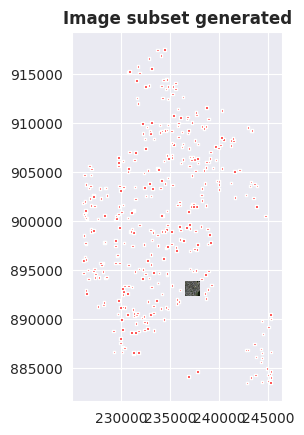

In [ ]:
#use box from shapely.geometry
b = df_chip_train_image_feature.apply(lambda row: box(row.x_min, #also called left
                                  row.y_min, #also called bottom
                                  row.x_max, #also called right
                                  row.y_max, #also called top
                                  ccw=True),
                  axis=1)
gdf = gpd.GeoDataFrame(df_chip_train_image_feature, geometry=b)

##### How to combine plots with rasterio package
r_build = rasterio.open(files_df.files_sat[0])
fig, ax = plt.subplots()
rasterio.plot.show(r_build,ax=ax,
                  title="Image subset generated")
gdf.plot(ax=ax,
              color="red")

<Axes: title={'center': 'Image subset generated'}>

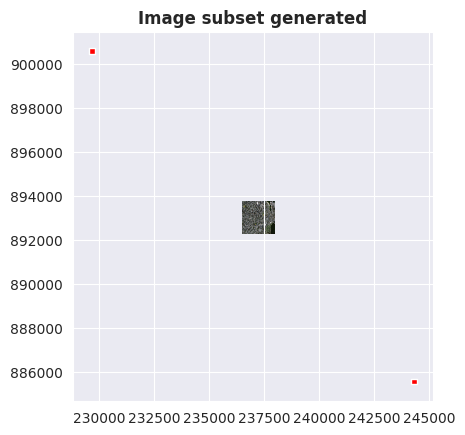

In [ ]:
#use box from shapely.geometry
b = df_chip_train_image_feature.apply(lambda row: box(row.x_min, #also called left
                                  row.y_min, #also called bottom
                                  row.x_max, #also called right
                                  row.y_max, #also called top
                                  ccw=True),
                  axis=1)
gdf = gpd.GeoDataFrame(df_chip_train_image_feature, geometry=b)

##### How to combine plots with rasterio package
r_build = rasterio.open(files_df.files_sat[0])
fig, ax = plt.subplots()
rasterio.plot.show(r_build,ax=ax,
                  title="Image subset generated")
gdf.loc[0:1,:].plot(ax=ax,
              color="red")

##3.2 Create custom dataset class for semantic segmentation


In [ ]:
image_dir = os.path.join(out_dir,'data','train','img_features')
#image_dir = os.path.join(out_dir,'data','train','img_features')

print(len(os.listdir(image_dir)))
os.listdir(image_dir)[:10]

605


['feature_patch_0_568_185_256_24478855_15.tif',
 'feature_patch_1_550_548_256_22979005_15.tif',
 'feature_patch_2_247_437_256_23278945_15.tif',
 'feature_patch_3_828_1065_256_23729110_15.tif',
 'feature_patch_4_330_207_256_22678960_15.tif',
 'feature_patch_5_1059_39_256_24029080_15.tif',
 'feature_patch_6_243_1242_256_23578990_15.tif',
 'feature_patch_7_1238_96_256_22978915_15.tif',
 'feature_patch_8_1238_1157_256_24179080_15.tif',
 'feature_patch_9_568_984_256_23279155_15.tif']

In [ ]:
#label_dir = os.path.join(out_dir,'data','train','img_labels')
label_dir = os.path.join(out_dir,'data','valid','img_labels')

print(len(os.listdir(label_dir)))
os.listdir(label_dir)[:10]#, os.listdir(image_dir)[-10:]

200


['label_patch_0_1001_994_256_23579050_15.tif',
 'label_patch_1_972_430_256_23728930_15.tif',
 'label_patch_2_1145_369_256_23429155_15.tif',
 'label_patch_3_779_809_256_23728930_15.tif',
 'label_patch_4_600_167_256_23579050_15.tif',
 'label_patch_5_156_516_256_23579050_15.tif',
 'label_patch_6_843_340_256_23579050_15.tif',
 'label_patch_7_283_197_256_23579050_15.tif',
 'label_patch_8_1077_1126_256_23579050_15.tif',
 'label_patch_9_467_60_256_23579050_15.tif']

https://discuss.pytorch.org/t/how-make-customised-dataset-for-semantic-segmentation/30881/12

https://discuss.pytorch.org/t/how-make-customised-dataset-for-semantic-segmentation/30881/11

https://www.kaggle.com/code/ligtfeather/semantic-segmentation-is-easy-with-pytorch

https://www.learnpytorch.io/04_pytorch_custom_datasets/


In [ ]:
class SegDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir #
        self.label_dir = label_dir #target image with each pixel labeled as belonging to a class
        self.transform = transform
        self.images = os.listdir(image_dir) #make sure that the order match label images
        self.labels = os.listdir(label_dir)
        # Ensure the images and masks are sorted in the same order
        #self.images.sort()
        #self.labels.sort()
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.images[idx])
        label_path = os.path.join(self.label_dir, self.labels[idx])
        image = Image.open(image_path).convert("RGB")
        #label = Image.open(label_path).convert("L")  # "L" mode for grayscale masks, this will reduce the values of building to 76
        label = Image.open(label_path).getchannel(0)  # "L" mode for grayscale masks

        if self.transform:
            # let's apply image transform to image feature and labels
            image = self.transform(image)
            label = self.transform(label)
            label = label.long()     # Equivalent to tensor.to(torch.int64)

        return image, label


In [ ]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()])

<class 'PIL.Image.Image'>
(256, 256)
(256, 256)
('R', 'G', 'B')
('R', 'G', 'B')
RGB
RGB


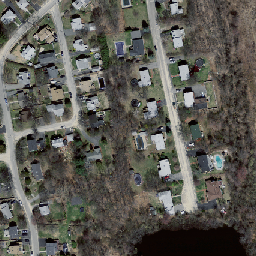

In [ ]:
image = Image.open(os.path.join(image_dir,os.listdir(image_dir)[0])).convert("RGB")
#label = Image.open(os.path.join(label_dir,os.listdir(label_dir)[0])).convert("L")
label = Image.open(os.path.join(label_dir,os.listdir(label_dir)[0]))

print(type(image))
print(label.size)
print(image.size)
print(image.getbands())
print(label.getbands())
print(image.mode)
print(label.mode) #8bits grey scale image with one channel
#print(label)
image

In [ ]:
print(label.getchannel(0).size)
print(len(label.getchannel(0).getbands()))
print((label.getchannel(0).mode))

#label_test.numpy()
#check if dataset is balanced.
unique_elements, counts_elements = np.unique(np.array(label.getchannel(0)), return_counts=True)
print("Frequency of unique values of the said array:")
print(np.asarray((unique_elements, counts_elements)))


(256, 256)
1
L
Frequency of unique values of the said array:
[[    0   255]
 [63567  1969]]


In [ ]:
#label_test.numpy()
#check if dataset is balanced.
unique_elements, counts_elements = np.unique(np.array(label), return_counts=True)
print("Frequency of unique values of the said array:")
print(np.asarray((unique_elements, counts_elements)))


Frequency of unique values of the said array:
[[     0    255]
 [194639   1969]]


In [ ]:
image_test= transform(image)
image_test

tensor([[[0.4392, 0.5216, 0.7765,  ..., 0.4588, 0.4745, 0.4431],
         [0.4627, 0.4824, 0.5098,  ..., 0.4980, 0.5255, 0.4392],
         [0.4078, 0.3922, 0.4667,  ..., 0.4784, 0.4000, 0.4039],
         ...,
         [0.4392, 0.3922, 0.3882,  ..., 0.2392, 0.2627, 0.1843],
         [0.4196, 0.4039, 0.4863,  ..., 0.1373, 0.1922, 0.1529],
         [0.3333, 0.4667, 0.5098,  ..., 0.1569, 0.2157, 0.2196]],

        [[0.4157, 0.4902, 0.7922,  ..., 0.4039, 0.4118, 0.3961],
         [0.4353, 0.4745, 0.4941,  ..., 0.4588, 0.4706, 0.3961],
         [0.4000, 0.3843, 0.4353,  ..., 0.4275, 0.3529, 0.3490],
         ...,
         [0.4039, 0.3804, 0.3882,  ..., 0.2314, 0.2471, 0.1922],
         [0.3922, 0.4118, 0.4784,  ..., 0.0980, 0.1882, 0.1333],
         [0.2902, 0.4706, 0.4824,  ..., 0.1333, 0.2000, 0.2118]],

        [[0.3725, 0.5020, 0.7725,  ..., 0.3569, 0.3804, 0.3765],
         [0.3843, 0.4353, 0.5098,  ..., 0.4196, 0.4157, 0.3608],
         [0.3373, 0.3216, 0.3843,  ..., 0.3804, 0.3294, 0.

In [ ]:
label_test= transform(label)
label_test

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [ ]:
#label_test.numpy()
#check if dataset is balanced.
unique_elements, counts_elements = np.unique(label_test.numpy(), return_counts=True)
print("Frequency of unique values of the said array:")
print(np.asarray((unique_elements, counts_elements)))


Frequency of unique values of the said array:
[[0.00000e+00 1.00000e+00]
 [1.94639e+05 1.96900e+03]]


In [ ]:
train_dataset = SegDataset(image_dir=os.path.join(out_dir,'data','train','img_features'),
           label_dir=os.path.join(out_dir,'data','train','img_labels'),
           transform=transform)

test_dataset = SegDataset(image_dir=os.path.join(out_dir,'data','test','img_features'),
           label_dir=os.path.join(out_dir,'data','test','img_labels'),
           transform=transform)

val_dataset = SegDataset(image_dir=os.path.join(out_dir,'data','valid','img_features'),
           label_dir=os.path.join(out_dir,'data','valid','img_labels'),
           transform=transform)

image_feature, image_label = train_dataset[1]
print(type(image_feature))
print(image_feature.shape)
print(len(train_dataset))
print(len(test_dataset))
print(len(val_dataset))
#print(image_feature.height)
#print(image_label.width)

<class 'torch.Tensor'>
torch.Size([3, 256, 256])
605
140
200


Let's now examine the output shape and types of the images:

- image: feature with 3 bands RGB in toch.float32 format of size 25x256
- label: also called mask image in the literature, it is the pixel labeled data in torch.int64 (long int format) of size 256x256.

Note that we converted the label image to torch long int because we are using a dice loss function that requires that format.



In [ ]:
type(image_feature)
print(type(image_label))
print(image_feature.shape)
print(image_label.shape)

print(image_label.dtype) #this needs to be pytorch torch.int64 or torch.long to use kornia dieceloss
print(image_feature.dtype)

<class 'torch.Tensor'>
torch.Size([3, 256, 256])
torch.Size([1, 256, 256])
torch.int64
torch.float32


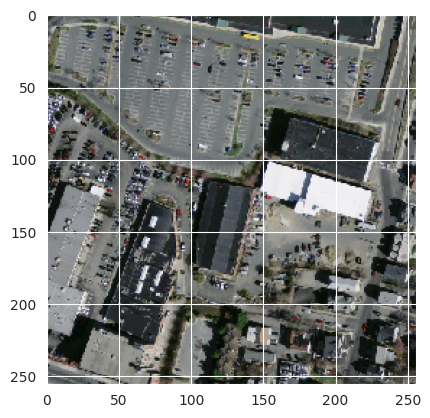

In [ ]:
plt.imshow(image_feature.squeeze().permute(1,2,0))

Frequency of unique values of the said array:
[[    0     1]
 [49791 15745]]


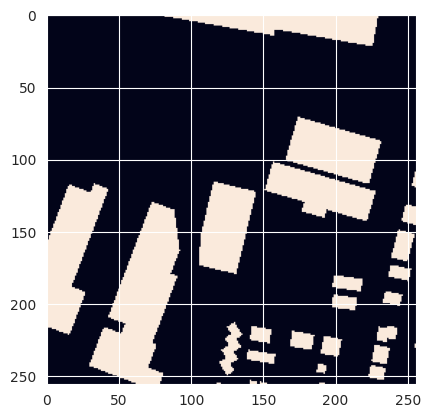

In [ ]:

#label_test.numpy()
#check if dataset is balanced.
unique_elements, counts_elements = np.unique(image_label.numpy(), return_counts=True)
print("Frequency of unique values of the said array:")
print(np.asarray((unique_elements, counts_elements)))

plt.imshow(image_label.squeeze().numpy())

##3.3 Data loader

In [ ]:
batch_size = 32
train_dataloader = torch.utils.data.DataLoader(train_dataset,
                                               batch_size=batch_size,
                                               shuffle=True,
                                               num_workers=2)

val_dataloader = torch.utils.data.DataLoader(val_dataset,
                                               batch_size=batch_size,
                                               shuffle=True,
                                               num_workers=2)

test_dataloader = torch.utils.data.DataLoader(test_dataset,
                                               batch_size=batch_size,
                                               shuffle=True,
                                               num_workers=2)



We can check the size of batch size and the number of batches to compute the number of images for training:
- the batch size is 32
- 13 batches
- last batch is smaller and contains 16 images (32*13-400)

In [ ]:
print(train_dataloader.batch_size)
print(len(train_dataloader))
print(len(train_dataloader)*train_dataloader.batch_size)


32
19
608


Feature batch shape: torch.Size([32, 3, 256, 256])
Labels batch shape: torch.Size([32, 1, 256, 256])


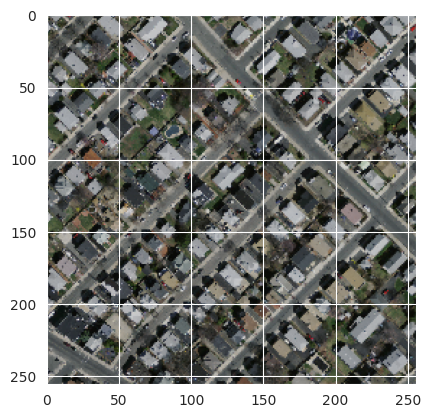

Label: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]])


In [ ]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img.permute(1,2,0))
plt.show()
print(f"Label: {label}")

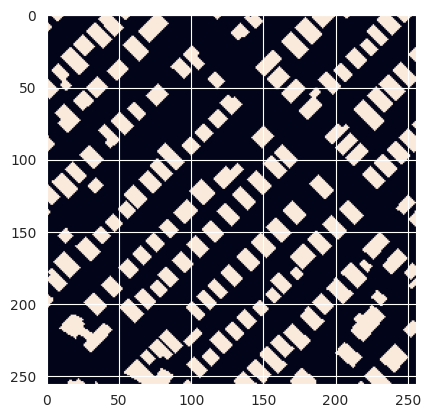

In [ ]:
plt.imshow(label.squeeze())

Using the image data generator, we can access one item. Note that both the original RGB feature image and target image (buildings mapped) are returned in the form of numpy arrays. This is a four dimensional array with:
- the first dimension corresponding to the number of batches.
- second dimension to the height (row) of the image
- third dimension to the width (column) of the image
- fourth dimension corresponding to the number of channels

Feature batch shape: torch.Size([32, 3, 256, 256])
Labels batch shape: torch.Size([32, 1, 256, 256])


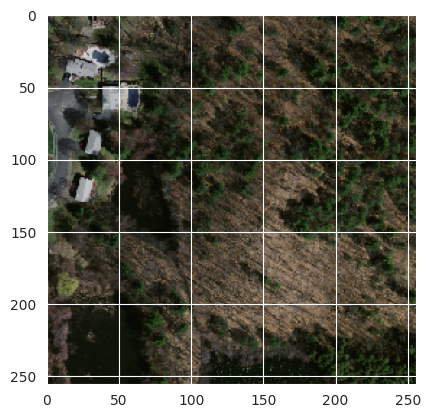

Label: tensor([[[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]])


In [ ]:
# Display image and label.
val_features, val_labels = next(iter(val_dataloader))
print(f"Feature batch shape: {val_features.size()}")
print(f"Labels batch shape: {val_labels.size()}")
img = val_features[0].squeeze()
label = val_labels[0]
plt.imshow(img.permute(1,2,0))
plt.show()
print(f"Label: {label}")

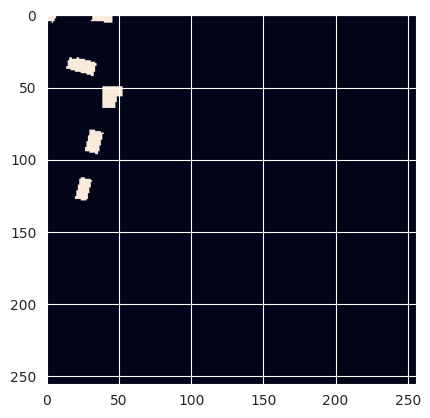

In [ ]:
plt.imshow(label.squeeze())

#4.Building model

The model we are builing in this exercise is called UNET due to the shape of its reprentation (https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/).
![UNET](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

UNET is a form of Fully Convolutional Network with three main parts:
- encoding (compression with pooling)
- decoding (decompression with upsampling)
- classification (CNN layer)

It is a form of autoencoder adapted for pixel level classification. The output layer has the same spatial dimension as the input but with one band/channel corresponding to the probability of a pixel being labeled as 'built'.


Links:

https://medium.com/@fernandopalominocobo/mastering-u-net-a-step-by-step-guide-to-segmentation-from-scratch-with-pytorch-6a17c5916114

https://baratam-tarunkumar.medium.com/land-cover-classification-with-u-net-aa618ea64a1b

https://medium.com/@sooryanarayan_5231/training-a-unet-model-for-geospatial-deep-learning-a-step-by-step-guide-in-google-colab-84edfd8a94d9

https://wvview.org/dl/pytorch_examples/quarto/T14_Train_UNet.html

https://wvview.org/geospatdl.html

https://towardsdatascience.com/cook-your-first-u-net-in-pytorch-b3297a844cf3/

transpose convolution: https://towardsdatascience.com/transposed-convolution-demystified-84ca81b4baba/




In [ ]:
#https://medium.com/@sooryanarayan_5231/training-a-unet-model-for-geospatial-deep-learning-a-step-by-step-guide-in-google-colab-84edfd8a94d9
import torch.nn.functional as F

class encoderBlock(nn.Module):
  def __init__(self,in_features, out_features):
    super(encoderBlock, self).__init__()

    self.convBlock =  nn.Sequential(
                                  nn.Conv2d(in_channels = in_features, out_channels= out_features, kernel_size=(3,3),stride =(1, 1), padding='same'),
                                  nn.BatchNorm2d(out_features),
                                  nn.ReLU(),
                                  nn.Conv2d(in_channels = out_features,out_channels= out_features, kernel_size=(3, 3), stride=(1,1), padding='same'),
                                  nn.BatchNorm2d(out_features),
                                  nn.ReLU(),
                                  )
    self.pool = nn.MaxPool2d((2, 2), stride=(2, 2))

  def forward(self, x):

      encoder =  self.convBlock(x)
      encoder_pool = self.pool(encoder)
      return encoder_pool, encoder



In [ ]:
class decoderBlock(nn.Module):
  def __init__(self,in_features, out_features):
    super(decoderBlock, self).__init__()
    #512 in , out 256
    self.convTranspose =  nn.ConvTranspose2d(in_channels=in_features,out_channels=out_features, kernel_size=(2, 2), stride=(2, 2))
    self.batchnorm1 = nn.BatchNorm2d(in_features)
    self.conv1 = nn.Conv2d(in_channels=in_features,out_channels=out_features,kernel_size=(3,3),stride=(1,1),padding='same')
    self.batchnorm2 = nn.BatchNorm2d(out_features)
    self.conv2 = nn.Conv2d(in_channels=out_features,out_channels=out_features,kernel_size=(3,3),stride=(1,1),padding='same')

  def forward(self, x,concat_tensor):

      x =  self.convTranspose(x) #out shape: 256 channels
      x = torch.cat([x, concat_tensor], dim=1) #256+256 channels
      x = self.batchnorm1(x)#takes in 512 channels
      x = F.relu(x)
      x = self.conv1(x)#in: 512, out 256
      x = self.batchnorm2(x) #aded: in 256
      x = F.relu(x) #added
      x = self.conv2(x)#added: in 256 out 26
      x = self.batchnorm2(x) #in 2556
      decoder = F.relu(x)
      return decoder

In [ ]:

class UnetModel(nn.Module):
  def __init__(self,input_size, num_classes):
    super(UnetModel, self).__init__()

    self.encoder_block1 =  encoderBlock(input_size,32)
    self.encoder_block2  =  encoderBlock(32,64)
    self.encoder_block3 =  encoderBlock(64,128)
    self.encoder_block4  =  encoderBlock(128,256)

    self.conv_block = nn.Conv2d(256,512, kernel_size=(3,3),stride=(1,1),padding='same') #change to 512

    self.decoder_block4 =  decoderBlock(512,256)
    self.decoder_block3  =  decoderBlock(256,128)
    self.decoder_block2 =  decoderBlock(128,64)
    self.decoder_block1  =  decoderBlock(64,32)

    self.classifier = nn.Sequential(
                                   nn.Conv2d(32,num_classes, kernel_size=(1, 1),stride=(1,1),padding='same'),
                                   nn.Sigmoid()
                                   )

  def forward(self, x):
                                                    #3x256x256
    encoder1_pool, encoder1 = self.encoder_block1(x) #32x128x128
    encoder2_pool, encoder2 = self.encoder_block2(encoder1_pool) #64x64x64
    encoder3_pool, encoder3 = self.encoder_block3(encoder2_pool) #128x32x32
    encoder4_pool, encoder4 = self.encoder_block4(encoder3_pool) #output: 256x16x16

    center = self.conv_block(encoder4_pool) #512x16x16

    decoder4 = self.decoder_block4(center, encoder4) #output:256x32x32
    decoder3 = self.decoder_block3(decoder4,encoder3) #128x64x64
    decoder2 = self.decoder_block2(decoder3,encoder2) #64x128x128
    decoder1 = self.decoder_block1(decoder2,encoder1) #32x256x256

    outputs = self.classifier(decoder1) #1x256x256
    return outputs


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_unet = UnetModel(input_size=3,num_classes=1).to(device)
model_unet

UnetModel(
  (encoder_block1): encoderBlock(
    (convBlock): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
    (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (encoder_block2): encoderBlock(
    (convBlock): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
    (pool): Max

In [ ]:
# Print a summary using torchinfo (uncomment for actual output)
#from torchsummary import summary
from torchinfo import summary

summary(model=model_unet,
        input_size=(32, 3, 256, 256), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
UnetModel (UnetModel)                         [32, 3, 256, 256]    [32, 1, 256, 256]    --                   True
├─encoderBlock (encoder_block1)               [32, 3, 256, 256]    [32, 32, 128, 128]   --                   True
│    └─Sequential (convBlock)                 [32, 3, 256, 256]    [32, 32, 256, 256]   --                   True
│    │    └─Conv2d (0)                        [32, 3, 256, 256]    [32, 32, 256, 256]   896                  True
│    │    └─BatchNorm2d (1)                   [32, 32, 256, 256]   [32, 32, 256, 256]   64                   True
│    │    └─ReLU (2)                          [32, 32, 256, 256]   [32, 32, 256, 256]   --                   --
│    │    └─Conv2d (3)                        [32, 32, 256, 256]   [32, 32, 256, 256]   9,248                True
│    │    └─BatchNorm2d (4)                   [32, 32, 256, 256]   [32, 32, 256, 256]

In [ ]:
(model_unet.state_dict().keys())

odict_keys(['encoder_block1.convBlock.0.weight', 'encoder_block1.convBlock.0.bias', 'encoder_block1.convBlock.1.weight', 'encoder_block1.convBlock.1.bias', 'encoder_block1.convBlock.1.running_mean', 'encoder_block1.convBlock.1.running_var', 'encoder_block1.convBlock.1.num_batches_tracked', 'encoder_block1.convBlock.3.weight', 'encoder_block1.convBlock.3.bias', 'encoder_block1.convBlock.4.weight', 'encoder_block1.convBlock.4.bias', 'encoder_block1.convBlock.4.running_mean', 'encoder_block1.convBlock.4.running_var', 'encoder_block1.convBlock.4.num_batches_tracked', 'encoder_block2.convBlock.0.weight', 'encoder_block2.convBlock.0.bias', 'encoder_block2.convBlock.1.weight', 'encoder_block2.convBlock.1.bias', 'encoder_block2.convBlock.1.running_mean', 'encoder_block2.convBlock.1.running_var', 'encoder_block2.convBlock.1.num_batches_tracked', 'encoder_block2.convBlock.3.weight', 'encoder_block2.convBlock.3.bias', 'encoder_block2.convBlock.4.weight', 'encoder_block2.convBlock.4.bias', 'encode

Let's try to use the model one one bacth.

In [ ]:
train_features, train_labels = next(iter(train_dataloader))
train_features.shape

torch.Size([32, 3, 256, 256])

In [ ]:
  # Forward pass
  #outputs = model_unet(inputs)

outputs = model_unet(train_features)
outputs.shape

torch.Size([32, 1, 256, 256])

In [ ]:
outputs

tensor([[[[0.5950, 0.4015, 0.5253,  ..., 0.5810, 0.6077, 0.6101],
          [0.5789, 0.3673, 0.5442,  ..., 0.4951, 0.5312, 0.4957],
          [0.5507, 0.4223, 0.5354,  ..., 0.6219, 0.5365, 0.5063],
          ...,
          [0.5388, 0.5448, 0.5563,  ..., 0.5167, 0.5783, 0.4956],
          [0.4751, 0.4522, 0.5541,  ..., 0.4998, 0.5888, 0.6137],
          [0.5739, 0.5603, 0.5180,  ..., 0.4824, 0.4787, 0.5487]]],


        [[[0.5401, 0.4995, 0.5040,  ..., 0.5555, 0.5773, 0.4825],
          [0.5396, 0.6061, 0.4877,  ..., 0.6642, 0.5073, 0.4844],
          [0.5203, 0.4742, 0.5349,  ..., 0.6634, 0.5886, 0.6095],
          ...,
          [0.5643, 0.5743, 0.5679,  ..., 0.5346, 0.5501, 0.5135],
          [0.4847, 0.5252, 0.6000,  ..., 0.5928, 0.5884, 0.5060],
          [0.5766, 0.5897, 0.5704,  ..., 0.5236, 0.4844, 0.5970]]],


        [[[0.4564, 0.4974, 0.5336,  ..., 0.5479, 0.5878, 0.5563],
          [0.3724, 0.5234, 0.3582,  ..., 0.5484, 0.5223, 0.5020],
          [0.4268, 0.5264, 0.6485,  ..

https://medium.com/data-scientists-diary/implementation-of-dice-loss-vision-pytorch-7eef1e438f68


In [ ]:
import torch
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1):
    """
    Computes the Dice Loss for binary segmentation.
    Args:
        pred: Tensor of predictions (batch_size, 1, H, W).
        target: Tensor of ground truth (batch_size, 1, H, W).
        smooth: Smoothing factor to avoid division by zero.
    Returns:
        Scalar Dice Loss.
    """
    # Apply sigmoid to convert logits to probabilities
    pred = torch.sigmoid(pred)

    # Calculate intersection and union
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))

    # Compute Dice Coefficient
    dice = (2. * intersection + smooth) / (union + smooth)

    # Return Dice Loss
    return 1 - dice.mean()

class DiceLoss:
    def __init__(self, smooth=1):
        self.smooth = smooth

    def __call__(self, pred, target):
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

class CustomDiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super(CustomDiceLoss, self).__init__()
        self.smooth = smooth
    def forward(self, pred, target):
        #pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

        #return torch.mean((predictions - targets) ** 2)

In [ ]:
dice_loss_fn = CustomDiceLoss()

In [ ]:
dice_loss

<function __main__.dice_loss(pred, target, smooth=1)>

In [ ]:
loss=dice_loss_fn(outputs,train_labels)
loss

tensor(0.8491, grad_fn=<RsubBackward1>)

dice_loss:

- https://cvinvolution.medium.com/dice-loss-in-medical-image-segmentation-d0e476eb486

- https://www.kaggle.com/code/bigironsphere/loss-function-library-keras-pytorch

- korning paper: https://arxiv.org/pdf/1910.02190


Let's use the DICE loss for the training. We will use the implementation from the kornia package:

https://kornia.readthedocs.io/en/v0.6.3/_modules/kornia/losses/dice.html

#5.Training model

It takes about 1 hours for 20 epochs.

In [ ]:
train_model = False

In [ ]:
#took about 5 minutes for one epochs

#seed_value = 42
#torch.manual_seed(seed_value) #for training reproducibiligy
#np.random.seed(seed_value) #for GPU and CPU operations reproducibliy

#loss_fn = nn.CrossEntropyLoss()
#loss_fn = kornia.losses.DiceLoss()

#train_model = False
if train_model is True:
  loss_fn = CustomDiceLoss()

  optimizer = torch.optim.Adam(model_unet.parameters(), lr=0.01)

  # 4. Training loop
  epochs = 1
  train_loss_list = []
  list_df_train_loss = []
  list_df_loss = []
  list_df_loss_val = []
  list_batch_number = []
  for epoch in range(epochs):
    model_unet.train(True) # Set model to training mode
    train_loss = 0.0
    for batch_val, data in enumerate(train_dataloader):
      inputs, labels = data
      # Zero the gradients
      optimizer.zero_grad()
      # Forward pass
      outputs = model_unet(inputs)
      # Calculate loss
      loss = loss_fn(outputs, labels)
      # Backward pass and optimization
      loss.backward()
      optimizer.step() #update the weights
      train_loss  += loss.item()
      df_loss_train = pd.DataFrame({'batch_number':[batch_val],
                              'loss':[loss.item()],
                              'epoch': [epoch]})
      list_df_loss.append(df_loss_train)

    df_train_loss_val = pd.DataFrame({'train_loss':[train_loss],
                                  'epoch': [epoch]})
    train_loss_list.append(train_loss)
    list_df_train_loss.append(df_train_loss_val)

    ### Add validation

    list_df_pred = []
    model_unet.eval() # Set model to avaluation mode
    val_loss = 0.0
    for batch_val, data in enumerate(val_dataloader):
      inputs, labels = data
      # Zero the gradients
      # Forward pass
      with torch.inference_mode():
        outputs = model_unet(inputs) #forward path
        # Find the Loss
        loss = loss_fn(outputs,labels)
        # Calculate Loss
        val_loss += loss.item()
        df_loss_val = pd.DataFrame({'batch_number':[batch_val],
                              'loss':[loss.item()],
                              'epoch': [epoch]})
        list_df_loss_val.append(df_loss_val)


    ### Now print results
    print(f'Epoch {epoch+1}/{epochs}, train Loss: {train_loss:.4f}')
    print(f'Epoch {epoch+1}/{epochs}, val Loss: {val_loss:.4f}')

  #maybe add validation
  df_train_loss = pd.concat(list_df_train_loss)
  df_val_loss = pd.concat(list_df_loss_val)
  loss_df = pd.concat(list_df_loss).reset_index(drop=True)
  loss_val_df = pd.concat(list_df_loss_val).reset_index(drop=True)

  print("Saved model to disk ", model_name)

else:
  print("No training: loading pretrained weights")
  del model_unet
  #device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model_unet = UnetModel(input_size=3,num_classes=1).to(device)
  #model_unet
  #model = MyModel()
  # Use weights_only=True for best practice when loading weights
  model_pretrained = glob.glob(os.path.join(model_path,'*.pth'))[0]
  print("Using weights from ",model_pretrained)
  checkpoint = torch.load(model_pretrained, weights_only=True)
  model_unet.load_state_dict(checkpoint)

  #Now load loss csv

  loss_val_filename = glob.glob(os.path.join(model_path,'*loss_val*.csv'))[0]
  print(loss_val_filename)
  loss_val_df = pd.read_csv(loss_val_filename)
  #loss_val_df
  loss_train_filename = glob.glob(os.path.join(model_path,'*loss_train*.csv'))[0]
  print(loss_train_filename)
  loss_df = pd.read_csv(loss_train_filename)
  #loss_val_df



No training: loading pretrained weights
Using weights from  /content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/models/model_output_20260227/Copy of model_unet_semantic_seg_pytorch_20260210.pth
/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/models/model_output_20260227/Copy of loss_val_model_unet_semantic_seg_pytorch_20260210.csv
/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/models/model_output_20260227/Copy of loss_train_model_unet_semantic_seg_pytorch_20260210.csv


In [ ]:
model_unet.state_dict().keys()

odict_keys(['encoder_block1.convBlock.0.weight', 'encoder_block1.convBlock.0.bias', 'encoder_block1.convBlock.1.weight', 'encoder_block1.convBlock.1.bias', 'encoder_block1.convBlock.1.running_mean', 'encoder_block1.convBlock.1.running_var', 'encoder_block1.convBlock.1.num_batches_tracked', 'encoder_block1.convBlock.3.weight', 'encoder_block1.convBlock.3.bias', 'encoder_block1.convBlock.4.weight', 'encoder_block1.convBlock.4.bias', 'encoder_block1.convBlock.4.running_mean', 'encoder_block1.convBlock.4.running_var', 'encoder_block1.convBlock.4.num_batches_tracked', 'encoder_block2.convBlock.0.weight', 'encoder_block2.convBlock.0.bias', 'encoder_block2.convBlock.1.weight', 'encoder_block2.convBlock.1.bias', 'encoder_block2.convBlock.1.running_mean', 'encoder_block2.convBlock.1.running_var', 'encoder_block2.convBlock.1.num_batches_tracked', 'encoder_block2.convBlock.3.weight', 'encoder_block2.convBlock.3.bias', 'encoder_block2.convBlock.4.weight', 'encoder_block2.convBlock.4.bias', 'encode

In [ ]:
print(model_unet.decoder_block4.convTranspose.weight.shape)
print(model_unet.decoder_block4.convTranspose.bias.shape)
len(list(model_unet.named_parameters()))

torch.Size([512, 256, 2, 2])
torch.Size([256])


76

In [ ]:
#run this during sesssion
'''
for name, param in list(model_unet.named_parameters())[:2]:
    print(f"Layer: {name} | Size: {param.size()}")
    print(param.data)
'''

'\nfor name, param in list(model_unet.named_parameters())[:2]:\n    print(f"Layer: {name} | Size: {param.size()}")\n    print(param.data)\n'

In [ ]:
os.listdir(model_path)
#loss_val_filename = glob.glob(os.path.join(model_path,'*loss_val*.csv'))[0]
#print(loss_val_filename)
#loss_val_df = pd.read_csv(loss_val_filename)
#loss_val_df


['Copy of loss_train_model_unet_semantic_seg_pytorch_20260210.csv',
 'Copy of model_unet_semantic_seg_pytorch_20260210.pth',
 'Copy of loss_val_model_unet_semantic_seg_pytorch_20260210.csv']

In [ ]:
loss_val_df

,batch_number,loss,epoch
0,0,0.776997,0
1,1,0.789904,0
2,2,0.821902,0
3,3,0.829516,0
4,0,0.744416,1
...,...,...,...
75,3,0.432609,18
76,0,0.527468,19
77,1,0.463634,19
78,2,0.524405,19


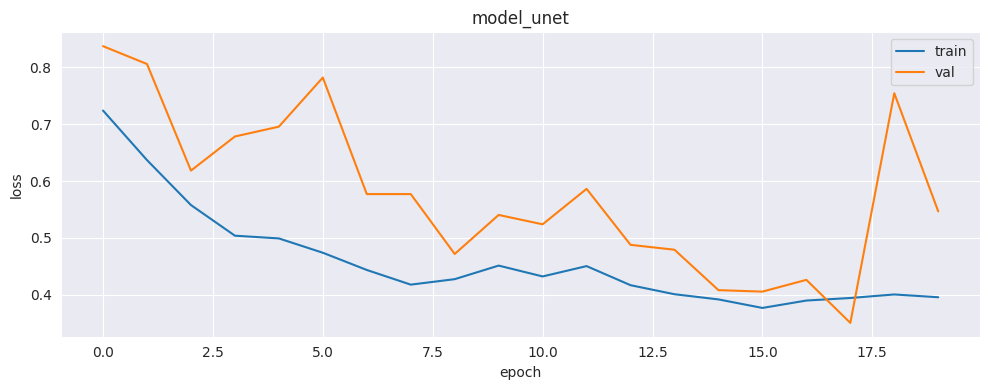

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(10,4))
plot_col = 'mean_loss'
model_name = 'model_unet'
#df_loss_agg = loss_df

df_loss_train_agg = loss_df
df_loss_val_agg = loss_val_df
df_loss_train_agg = (df_loss_train_agg.groupby('epoch')
                    .agg({'loss':['mean','sum']})
                    .set_axis(['mean_loss','sum_loss'],axis=1)
                    .reset_index()
                    )
df_loss_val_agg = (df_loss_val_agg.groupby('epoch')
                    .agg({'loss':['mean','sum']})
                    .set_axis(['mean_loss','sum_loss'],axis=1)
                    .reset_index()
                    )

df_loss_val_agg['loss']= round(df_loss_val_agg[plot_col],4)
df_loss_train_agg['loss']= round(df_loss_train_agg[plot_col],4)

df_loss_val_agg.rename(columns={'loss':'val_loss'},inplace=True)
df_loss_train_agg.rename(columns={'loss':'train_loss'},inplace=True)

df_loss_agg = (pd.concat([
    df_loss_val_agg.drop(columns=['mean_loss','sum_loss']),
    df_loss_train_agg.drop(columns=['epoch','mean_loss','sum_loss'])],axis=1))
df_loss_agg

ax.ticklabel_format(useOffset=False)
ax.plot(df_loss_agg['epoch'].values,
                    df_loss_agg['train_loss'].values,
                    label='train')
ax.plot(df_loss_agg['epoch'].values,
                    df_loss_agg['val_loss'].values,
                    label='val')
#ax[model_val].plot(hist_df['epoch'],hist_df['val_accuracy'],label='val')
ax.set_title(model_name)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.legend()

fig.tight_layout()
plt.savefig(f'{model_name}_training_loss_comparison_{out_suffix}.png')



In [ ]:
print(model_path)

/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_semantic_segmentation/models/model_output_20260227


# 6.Accurary Assessment and model evaluation

We will assess the model using the test data. The steps as follow:

1. generate test samples and predict using the fitted model
2. visualize outputs as raster map
3. compute accuracy metrics using the ROC and AUC.
4. examine precision and recall for specific threshold
5. create a precision-recall curve
6. produce a IOU metric

In #1, we generate new image chips using test image data with the image data generator used earlier. For this exercise, we will generate 10 samples but more can be generated if we wish to increase the number of test samples. We can then predct for each pixel a score representing the probabily of belonging to the class 'built'.

In #2, we visualize the new prediction. First,we visualize the output probabilities from the model
(continuous value between 0 and 1). Second, we generate class prediction by using by setting the treshold to 0.5. Any pixel with probability higher than
0.5 is classified as building. A boolean map of error is generated to visualize the matrix of confusion at the pixel level.

In #3, we compute the ROC and AUC for all 10 test chip image. We also generate ROC plots and save results in a data frame.

Feature batch shape: torch.Size([32, 3, 256, 256])
Labels batch shape: torch.Size([32, 1, 256, 256])


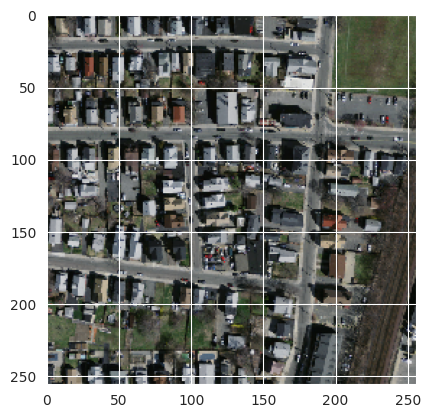

Label: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]]])


In [154]:
# Display image and label.
test_features, test_labels = next(iter(test_dataloader))
print(f"Feature batch shape: {test_features.size()}")
print(f"Labels batch shape: {test_labels.size()}")
img = test_features[0].squeeze()
label = test_labels[0]
plt.imshow(img.permute(1,2,0))
plt.show()
print(f"Label: {label}")

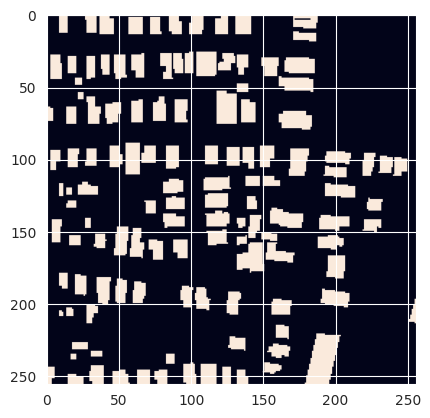

In [155]:
plt.imshow(label.squeeze())

Let's predict on this batch

In [156]:
#predictions = model.predict(w_X_test)
#model = list_models[2]
model_unet.eval()
y_scores = model_unet(test_features)

#y_score_logits = model_unet(test_features)
#print(y_score_logits.shape)
#y_scores = nn.Softmax(dim=1)(y_score_logits) #these are the proba
#y_scores.sum(dim=1)
#print(y_scores)
#y_pred_test = torch.argmax(y_scores, dim=1)  # Returns [1, 2]
#class_names[y_pred_test]
print(y_scores.shape)
print(y_scores[0,:,:,:].shape)
print(test_labels[0,:,:,:].shape)
y_scores[0,:,:,:] #gettting the first image predicted

torch.Size([32, 1, 256, 256])
torch.Size([1, 256, 256])
torch.Size([1, 256, 256])


tensor([[[2.1974e-06, 4.7921e-06, 4.9166e-06,  ..., 1.0928e-06,
          1.1842e-06, 2.6631e-06],
         [3.7995e-06, 8.8828e-06, 7.3909e-06,  ..., 9.0116e-07,
          1.0727e-06, 2.9426e-06],
         [3.1407e-06, 4.7992e-06, 3.3558e-06,  ..., 5.1537e-07,
          6.6261e-07, 2.1041e-06],
         ...,
         [9.9170e-01, 1.0000e+00, 1.0000e+00,  ..., 1.1216e-04,
          3.7931e-05, 2.3831e-05],
         [9.5457e-01, 9.9999e-01, 1.0000e+00,  ..., 6.2855e-05,
          2.5229e-05, 1.9946e-05],
         [2.3606e-01, 9.9864e-01, 9.9986e-01,  ..., 3.9249e-05,
          2.5173e-05, 1.5985e-05]]], grad_fn=<SelectBackward0>)

In [157]:
Y_pred = y_scores[0,:,:,:].detach().numpy().squeeze()
Y_test = test_labels[0,:,:,:].detach().numpy().squeeze()
X_test = test_features[0,:,:,:].detach().numpy().squeeze()

In [158]:
print(X_test.shape)
print(type(Y_pred))
Y_pred.shape

(3, 256, 256)
<class 'numpy.ndarray'>


(256, 256)

In [159]:
#plot one image for comparion:X,y-pred,y-test
#show error in one image and pixel matrix of confusion with precision and recall
#could also do IOU at building level
#do ROC for one image

Y_pred_cat = Y_pred > 0.5
Y_test
Y_pred_cat= Y_pred_cat.astype('int')
Y_test_cat = Y_test.astype('int')


In [160]:
r_crosstab, df_cross_tab = binary_crosstab_array(Y_test,Y_pred_cat)
r_crosstab

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [3, 1, 1, ..., 0, 0, 0]])

In [161]:
df_cross_tab


,val,label
0,0,TN
1,1,TP
2,2,FP
3,3,FN


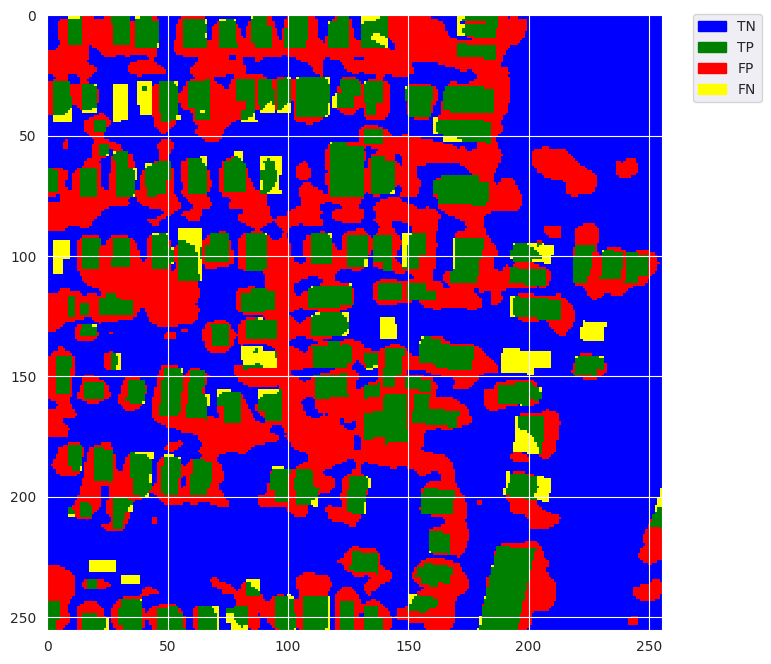

In [162]:
values = np.array([0,1,2,3])
# Create a list of labels to use for your legend
class_labels = ["TN",
                "TP",
                "FP",
                "FN"]

# Create a colormap from a list of colors
class_colors = ['blue',
                'green',
                'red',
                'yellow']
plt.figure(figsize=(16,8))

cmap_ramp = colors.ListedColormap(class_colors)
im = plt.imshow(r_crosstab, interpolation='none',cmap=cmap_ramp)

# get the colors of the values, according to the
# colormap used by imshow
colors_val = [ im.cmap(im.norm(value)) for value in values]
colors_val = class_colors
# create a patch (proxy artist) for every color
patches = [ mpatches.Patch(color=class_colors[i], label=class_labels[i]) for i in range(len(values)) ]
# put those patched as legend-handles into the legend
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0. )

plt.grid(True)
plt.show()

In [163]:
Y_test

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]])

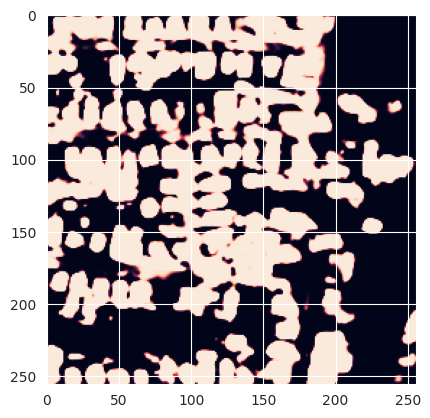

In [164]:
plt.imshow(Y_pred)

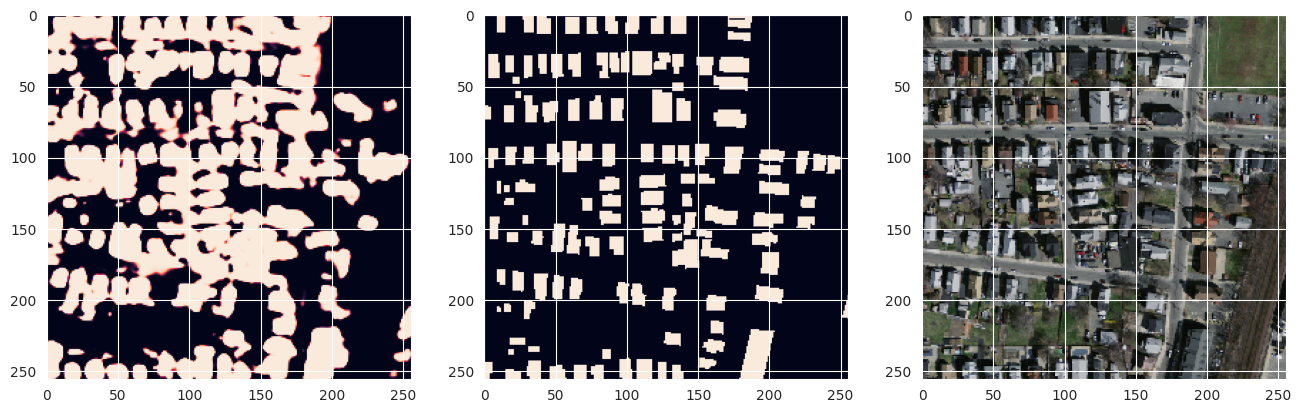

In [165]:
f, ax = plt.subplots(1, 3,figsize=(16,16))

ax[0].imshow(Y_pred)
ax[1].imshow(Y_test)
ax[2].imshow(X_test.transpose(1,2,0))


/tmp/ipython-input-283/430636422.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_pred.ravel())


<Axes: ylabel='Density'>

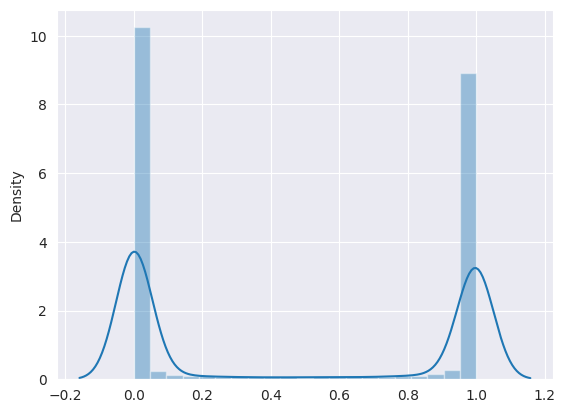

In [166]:
sns.distplot(Y_pred.ravel())

AUC train:  nan
AUC test:  0.854037437317729


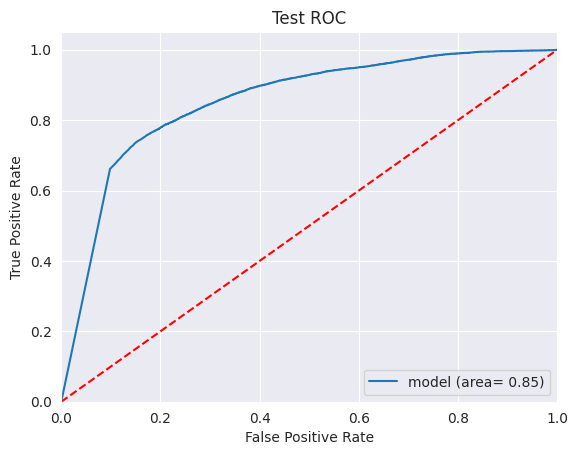

In [167]:
roc_df, auc_df = plot_roc(y_test=Y_test.ravel(),
         y_scores_test=Y_pred.ravel(),
         y_scores_train=None,
         y_train=None,
         model_name=None,
         show_fig=True,
         out_file=None)

In [168]:
y_test=Y_test.ravel()
y_scores_test=Y_pred.ravel()

threshold = 0.5


Y_pred_cat = y_scores_test > threshold
Y_pred_cat= Y_pred_cat.astype('int')
Y_test_cat = y_test.astype('int')

report_dict=classification_report(Y_test_cat,
                                  Y_pred_cat,
                                  output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
confusion_matrix_val = confusion_matrix(Y_test_cat,Y_pred_cat)
confusion_matrix_val
#https://towardsdatascience.com/what-metrics-should-we-use-on-imbalanced-data-set-precision-recall-roc-e2e79252aeba

array([[32930, 18286],
       [ 1748, 12572]])

In [169]:
report_df

,precision,recall,f1-score,support
0,0.949593,0.642963,0.766759,51216.000000
1,0.407415,0.877933,0.556554,14320.000000
accuracy,0.694305,0.694305,0.694305,0.694305
macro avg,0.678504,0.760448,0.661657,65536.000000
weighted avg,0.831124,0.694305,0.720828,65536.000000



|             | Pred 0      | Pred 1     |
| :---        |    :----:   |       ---: |
| True 0      | TN          | FP         |
| True 1      | FN          | TP         |

- precision = TP/(TP+FP)
- Recall = TP/(TP+FN) also called true positive rate or sensitivity, % of true positive cases recovered (not missed), if high a lot of misses
- FPR = FP/(FP+TN) , aslo called fall out FPR= 1- TNR
- TNR = TN/(TN+FP), also called specificity

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:996: FutureWarning: probas_pred was deprecated in version 1.5 and will be removed in 1.7.Please use ``y_score`` instead.
  warnings.warn(


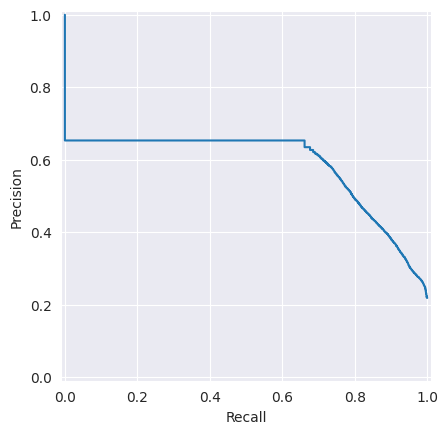

In [170]:
# Use sklearn to plot precision-recall curves

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
precision, recall, thresholds = precision_recall_curve(y_true=y_test,
                       probas_pred=y_scores_test)

prd = PrecisionRecallDisplay(precision, recall)
prd.plot()

In [171]:
from sklearn.metrics import precision_recall_curve, auc
AUC_prc = auc(recall, precision)
print(f"PR AUC via auc function: {AUC_prc}")

PR AUC via auc function: 0.7014121143546806


In [172]:
thresholds = np.insert(thresholds,0,0)
precision_recall_df = pd.DataFrame.from_dict({'thresholds':thresholds,
                        'precision':precision,
                        'recall':recall,
                        })

(precision_recall_df)

,thresholds,precision,recall
0,0.000000e+00,0.218506,1.000000
1,7.506803e-08,0.218509,1.000000
2,7.721023e-08,0.218513,1.000000
3,7.883179e-08,0.218516,1.000000
4,7.968303e-08,0.218519,1.000000
...,...,...,...
45010,9.999995e-01,0.621141,0.689804
45011,9.999996e-01,0.626797,0.685056
45012,9.999998e-01,0.634530,0.676536
45013,9.999999e-01,0.653016,0.661453


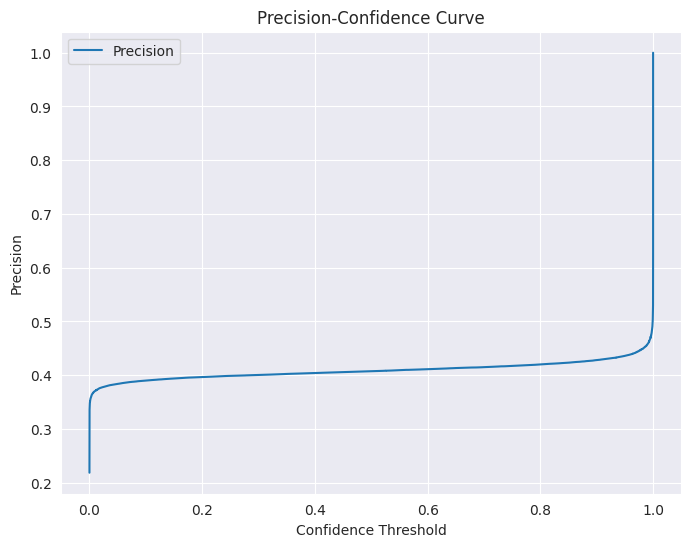

In [173]:
# Calculate precision, recall, and thresholds
#precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Plot the precision-confidence curve
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision, label='Precision')
plt.xlabel('Confidence Threshold')
plt.ylabel('Precision')
plt.title('Precision-Confidence Curve')
plt.grid(True)
plt.legend(loc='best')
plt.show()


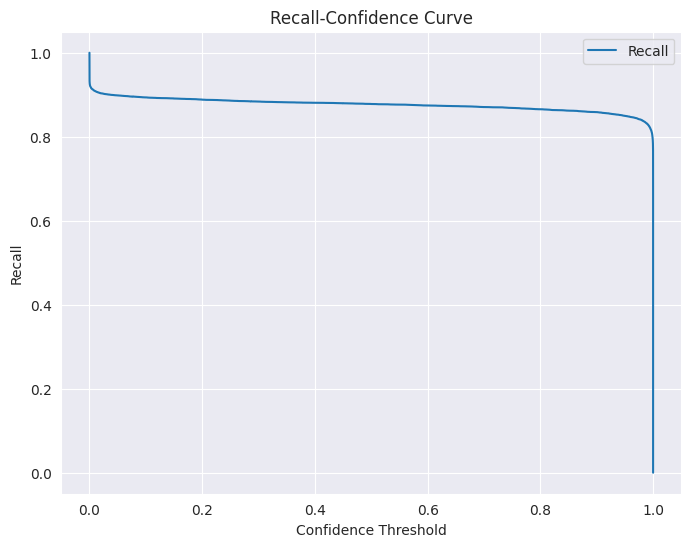

In [174]:
# Calculate precision, recall, and thresholds
#precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Plot the precision-confidence curve
plt.figure(figsize=(8, 6))
plt.plot(thresholds, recall, label='Recall')
plt.xlabel('Confidence Threshold')
plt.ylabel('Recall')
plt.title('Recall-Confidence Curve')
plt.grid(True)
plt.legend(loc='best')
plt.show()

In [175]:
# add IOU and precision-recall curve
target = Y_test_cat
prediction = Y_pred_cat
intersection = np.logical_and(target, prediction)
union = np.logical_or(target, prediction)
iou_score = np.sum(intersection) / np.sum(union)
iou_score

np.float64(0.38557320738514383)

## Changing score threshold

Testing at 0.8

In [176]:
y_test=Y_test.ravel()
y_scores_test=Y_pred.ravel()

threshold = 0.8

Y_pred_cat = y_scores_test > threshold
Y_pred_cat= Y_pred_cat.astype('int')
Y_test_cat = y_test.astype('int')

report_dict=classification_report(Y_test_cat,
                                  Y_pred_cat,
                                  output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
confusion_matrix_val = confusion_matrix(Y_test_cat,Y_pred_cat)
report_df
#https://towardsdatascience.com/what-metrics-should-we-use-on-imbalanced-data-set-precision-recall-roc-e2e79252aeba

,precision,recall,f1-score,support
0,0.946526,0.665983,0.781850,51216.000000
1,0.420102,0.865433,0.565632,14320.000000
accuracy,0.709564,0.709564,0.709564,0.709564
macro avg,0.683314,0.765708,0.673741,65536.000000
weighted avg,0.831499,0.709564,0.734605,65536.000000


In [177]:
# add IOU and precision-recall curve
target = Y_test_cat
prediction = Y_pred_cat
intersection = np.logical_and(target, prediction)
union = np.logical_or(target, prediction)
iou_score = np.sum(intersection) / np.sum(union)
iou_score

np.float64(0.39434244439494703)

## Examing more test data

In [179]:
list_auc_df = []
list_roc_df = []
for i in range(0,10):
    Y_pred = y_scores[i].detach().numpy().squeeze()
    Y_test = test_labels[i].detach().numpy().squeeze()
    X_test = test_features[i].detach().numpy().squeeze()

    y_test=Y_test.ravel()
    y_scores_test=Y_pred.ravel()

    precision, recall, thresholds = precision_recall_curve(y_true=y_test,
                       probas_pred=y_scores_test)
    AUC_prc = auc(recall, precision)
    print(f"PR AUC via auc function: {AUC_prc}")

    print('Batch number ',i)
    roc_df, auc_df = plot_roc(y_test=Y_test.ravel(),
         y_scores_test=Y_pred.ravel(),
         y_scores_train=None,
         y_train=None,
         model_name=None,
         show_fig=False,
         out_file=None)

    auc_df['auc_prc'] = AUC_prc

    list_auc_df.append(auc_df)
    list_roc_df.append(roc_df)
auc_df= pd.concat(list_auc_df)
#print(auc_df.test.mean())
auc_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:996: FutureWarning: probas_pred was deprecated in version 1.5 and will be removed in 1.7.Please use ``y_score`` instead.
  warnings.warn(


PR AUC via auc function: 0.7014121143546806
Batch number  0
AUC train:  nan
AUC test:  0.854037437317729


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:996: FutureWarning: probas_pred was deprecated in version 1.5 and will be removed in 1.7.Please use ``y_score`` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:996: FutureWarning: probas_pred was deprecated in version 1.5 and will be removed in 1.7.Please use ``y_score`` instead.
  warnings.warn(


PR AUC via auc function: 0.6648529496457556
Batch number  1
AUC train:  nan
AUC test:  0.8557560186159762
PR AUC via auc function: 0.6507686374520726
Batch number  2
AUC train:  nan
AUC test:  0.9491746447138044
PR AUC via auc function: 0.6952995191965567
Batch number  3
AUC train:  nan
AUC test:  0.8327909684269514


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:996: FutureWarning: probas_pred was deprecated in version 1.5 and will be removed in 1.7.Please use ``y_score`` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:996: FutureWarning: probas_pred was deprecated in version 1.5 and will be removed in 1.7.Please use ``y_score`` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


...

PR AUC via auc function: 0.62370384334845
Batch number  6
AUC train:  nan
AUC test:  0.8566728797261229
PR AUC via auc function: 0.8797572996636531
Batch number  7
AUC train:  nan
AUC test:  0.8272366987106716


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:996: FutureWarning: probas_pred was deprecated in version 1.5 and will be removed in 1.7.Please use ``y_score`` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:996: FutureWarning: probas_pred was deprecated in version 1.5 and will be removed in 1.7.Please use ``y_score`` instead.
  warnings.warn(


PR AUC via auc function: 0.6603165679486185
Batch number  8
AUC train:  nan
AUC test:  0.7190564835631578
PR AUC via auc function: 0.637674760058923
Batch number  9
AUC train:  nan
AUC test:  0.7498545893506054


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:996: FutureWarning: probas_pred was deprecated in version 1.5 and will be removed in 1.7.Please use ``y_score`` instead.
  warnings.warn(


,test,train,model,auc_prc
0,0.854037437317729,nan,model,0.701412
0,0.8557560186159762,nan,model,0.664853
0,0.9491746447138044,nan,model,0.650769
0,0.8327909684269514,nan,model,0.695300
0,nan,nan,model,0.500000
0,0.8468547471396203,nan,model,0.877646
0,0.8566728797261229,nan,model,0.623704
0,0.8272366987106716,nan,model,0.879757
0,0.7190564835631578,nan,model,0.660317
0,0.7498545893506054,nan,model,0.637675


#7.Conclusions

In this exercise, we created a UNET model using pytorch deep learning library to map built areas in Massachusets. We trained the model using CPU in colab (about 1h40 minutes) and generated a map of errors and a series of ROC plot for the test data. Here are few important points to note:

- the ROC curve may be misleading. It suggests good classification results but due to class imbalance (e.g. 16% pixel of building class in our example) the AUC is high (we predict no building easily.
- testing on one image at 0.5 threshold, we can see the recall is high (~0.77) but precision is lower (0.72) suggesting we are including pixels that are not building (False positives or error of commission). This is visible as red areas (False Positives) on the image plotted.
- The precision-recall curve is more informative. It shows a drastic drop in precision without improvement of recall. This curve is far from the top left.

- The IOU is around 0.6 so it suggests some improvement is needed to improve the predictions.

We can see some variations across iamges as suggested in the ROC values. Our assessment only considered one image. We should compute full test assessment using all 100 image chips created and generate averages.

This suggests the model may need some revision or retraining with more data.

In [ ]:
############################# END OF SCRIPT ###################################